# Embedding analysis — transformed variables
Same as `analyses.ipynb` (Q1–Q4) but with target variables transformed before fitting.
ACS targets: logit (moderate %%), √ (sparse %%), log1p ($ / counts).  PLACES targets: logit.
Use this notebook to check whether R² rankings change under transformation.

## Q1: What's the correlation between embeddings and the data elements from ACS that make up major area-based social risk indices?
We're using data from ReADI, SDI, and SVI. The script `get_data.py` pulls tract-level ACS data from the Census API (if it's not already present in the `data` folder). Then, we use LightGBM to estimate how much of the variance in tract-level values can be explained by embeddings.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score
import lightgbm as lgb
from scipy.special import logit as scipy_logit
import matplotlib.pyplot as plt

DATA_DIR    = Path("../../data")
OUTPUTS_DIR = Path("../../outputs/outputs_logit")
OUTPUTS_DIR.mkdir(exist_ok=True)

# ── Cache control ─────────────────────────────────────────────────────────────
# When True, each model cell loads its CSV from OUTPUTS_DIR instead of refitting.
# Set to False to rerun all LightGBM models from scratch.
USE_CACHED = True

STAT_SUFFIXES = ["MEAN", "MEDIAN", "MINIMUM", "MAXIMUM", "STD"]
EMB_COLS = [f"A{i:02d}_{s}" for i in range(64) for s in STAT_SUFFIXES]  # 320 cols
FEATURE_COLS = EMB_COLS + ["ALAND", "AWATER"]

In [2]:
acs_path = DATA_DIR / "acs.csv"

if not acs_path.exists():
    print("data/acs.csv not found — running get_data.py (~5 min for all 50 states)...")
    result = subprocess.run(
        [sys.executable, "get_data.py"],
        capture_output=True,
        text=True,
    )
    print(result.stdout[-3_000:] if len(result.stdout) > 3_000 else result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
else:
    print(f"✓  ACS data present: {acs_path}")

✓  ACS data present: ../../data/acs.csv


In [3]:
# Data is already aggregated to tract level; just filter to 2022 and select
# the embedding stat columns plus land/water area as geographic controls.
emb_tract = (
    pl.read_csv(DATA_DIR / "alphaearth_embeddings.csv", infer_schema_length=10_000)
    .filter((pl.col("year") == 2022) & pl.col("A00_MAXIMUM").is_not_null())
    .with_columns(
        pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips")
    )
    .select(["tract_fips"] + EMB_COLS + ["ALAND", "AWATER"])
)

print(f"Tracts with 2022 embeddings: {len(emb_tract):,}")
print(f"Feature columns: {len(FEATURE_COLS)}  ({len(EMB_COLS)} embedding stats + 2 area)")
emb_tract.head(3)

Tracts with 2022 embeddings: 85,528
Feature columns: 322  (320 embedding stats + 2 area)


tract_fips,A00_MEAN,A00_MEDIAN,A00_MINIMUM,A00_MAXIMUM,A00_STD,A01_MEAN,A01_MEDIAN,A01_MINIMUM,A01_MAXIMUM,A01_STD,A02_MEAN,A02_MEDIAN,A02_MINIMUM,A02_MAXIMUM,A02_STD,A03_MEAN,A03_MEDIAN,A03_MINIMUM,A03_MAXIMUM,A03_STD,A04_MEAN,A04_MEDIAN,A04_MINIMUM,A04_MAXIMUM,A04_STD,A05_MEAN,A05_MEDIAN,A05_MINIMUM,A05_MAXIMUM,A05_STD,A06_MEAN,A06_MEDIAN,A06_MINIMUM,A06_MAXIMUM,A06_STD,A07_MEAN,…,A57_MEAN,A57_MEDIAN,A57_MINIMUM,A57_MAXIMUM,A57_STD,A58_MEAN,A58_MEDIAN,A58_MINIMUM,A58_MAXIMUM,A58_STD,A59_MEAN,A59_MEDIAN,A59_MINIMUM,A59_MAXIMUM,A59_STD,A60_MEAN,A60_MEDIAN,A60_MINIMUM,A60_MAXIMUM,A60_STD,A61_MEAN,A61_MEDIAN,A61_MINIMUM,A61_MAXIMUM,A61_STD,A62_MEAN,A62_MEDIAN,A62_MINIMUM,A62_MAXIMUM,A62_STD,A63_MEAN,A63_MEDIAN,A63_MINIMUM,A63_MAXIMUM,A63_STD,ALAND,AWATER
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
"""01001020502""",-0.126687,-0.124567,-0.214133,-0.062991,0.036529,-0.262154,-0.284444,-0.374256,-0.010396,0.081945,0.028758,0.035433,-0.044844,0.103406,0.037766,0.231924,0.236463,0.135886,0.327812,0.040065,-0.012322,-0.010396,-0.059116,0.038447,0.023526,-0.06238,-0.055363,-0.179377,0.044844,0.061015,-0.049398,-0.051734,-0.113741,0.055363,0.038908,-0.119778,…,0.107417,0.108512,0.048228,0.166336,0.023226,0.137117,0.1417301,0.041584,0.172795,0.027567,-0.198787,-0.199862,-0.27614,-0.103406,0.031505,0.019465,0.027128,-0.088827,0.071111,0.034168,-0.056167,-0.051734,-0.186082,0.041584,0.065075,-0.033764,-0.035433,-0.179377,0.119093,0.053748,-0.004075,-0.003937,-0.075356,0.084214,0.039721,2097390,379
"""01003010200""",0.020921,0.044844,-0.292872,0.199862,0.090018,-0.103394,-0.103406,-0.327812,0.044844,0.047456,-0.115249,-0.119093,-0.236463,0.071111,0.036789,0.147004,0.153787,-0.084214,0.364721,0.091966,-0.141209,-0.14173,-0.244152,0.051734,0.037703,-0.176356,-0.172795,-0.383914,0.048228,0.078249,-0.013051,-0.006849,-0.19291,0.108512,0.045113,0.037069,…,0.175245,0.179377,0.004983,0.327812,0.056529,0.114393,0.113741,-0.048228,0.318893,0.062499,-0.236092,-0.236463,-0.374256,-0.059116,0.058099,0.000665,-0.000925,-0.186082,0.172795,0.052247,-0.036958,-0.041584,-0.172795,0.108512,0.055325,0.121158,0.119093,-0.038447,0.301423,0.047081,0.107488,0.108512,0.001538,0.310096,0.03673,221797187,358878
"""01003010600""",-0.059354,-0.062991,-0.2599,0.135886,0.085717,-0.14562,-0.135886,-0.364721,0.010396,0.079902,-0.069505,-0.093564,-0.206936,0.119093,0.071586,0.213636,0.221453,0.015748,0.327812,0.070566,-0.133266,-0.135886,-0.221453,-0.012057,0.035606,-0.176809,-0.172795,-0.355309,-0.024606,0.064752,-0.001242,0.003937,-0.130165,0.124567,0.049648,0.008566,…,0.157432,0.153787,0.055363,0.27614,0.042541,0.119849,0.124567,-0.015748,0.251965,0.055771,-0.246755,-0.244152,-0.393695,-0.130165,0.052326,0.012997,0.019931,-0.108512,0.124567,0.049972,-0.06061,-0.06699,-0.19291,0.135886,0.06319,0.107424,0.113741,-0.108512,0.310096,0.059322,0.086333,0.088827,-0.038447,0.206936,0.044213,18578278,21477


In [4]:
# Prefer 2022 data where available; fall back to 2023 for measures not yet in 2022 release.
_places_raw = pl.read_csv(
    DATA_DIR / "PLACES__Local_Data_for_Better_Health__Census_Tract_Data__2025_release.csv",
    infer_schema_length=10_000,
)

# MeasureId → Short_Question_Text for readable axis labels in visualizations
PLACES_LABELS: dict[str, str] = dict(
    _places_raw.select(["MeasureId", "Short_Question_Text"])
    .unique()
    .iter_rows()
)

_places_long = (
    _places_raw
    .filter(pl.col("Year").is_in([2022, 2023]))
    .select(["Year", "LocationID", "MeasureId", "Data_Value"])
    .with_columns(
        pl.col("LocationID").cast(pl.Utf8).str.zfill(11).alias("tract_fips")
    )
    .drop("LocationID")
)

_measures_2022 = set(
    _places_long.filter(pl.col("Year") == 2022)["MeasureId"].unique().to_list()
)
_measures_2023_only = set(
    _places_long.filter(pl.col("Year") == 2023)["MeasureId"].unique().to_list()
) - _measures_2022

places_wide = (
    pl.concat([
        _places_long.filter((pl.col("Year") == 2022) & pl.col("MeasureId").is_in(_measures_2022)),
        _places_long.filter((pl.col("Year") == 2023) & pl.col("MeasureId").is_in(_measures_2023_only)),
    ])
    .drop("Year")
    .pivot(on="MeasureId", index="tract_fips", values="Data_Value")
)

PLACES_MEASURES = sorted([c for c in places_wide.columns if c != "tract_fips"])
print(f"PLACES: {len(places_wide):,} tracts × {len(PLACES_MEASURES)} measures")
print(f"  2022 measures ({len(_measures_2022)}): {sorted(_measures_2022)}")
print(f"  2023 fill-in ({len(_measures_2023_only)}): {sorted(_measures_2023_only)}")
places_wide.head(3)

PLACES: 83,522 tracts × 40 measures
  2022 measures (5): ['COLON_SCREEN', 'DENTAL', 'MAMMOUSE', 'SLEEP', 'TEETHLOST']
  2023 fill-in (35): ['ACCESS2', 'ARTHRITIS', 'BINGE', 'BPHIGH', 'BPMED', 'CANCER', 'CASTHMA', 'CHD', 'CHECKUP', 'CHOLSCREEN', 'COGNITION', 'COPD', 'CSMOKING', 'DEPRESSION', 'DIABETES', 'DISABILITY', 'EMOTIONSPT', 'FOODINSECU', 'FOODSTAMP', 'GHLTH', 'HEARING', 'HIGHCHOL', 'HOUSINSECU', 'INDEPLIVE', 'LACKTRPT', 'LONELINESS', 'LPA', 'MHLTH', 'MOBILITY', 'OBESITY', 'PHLTH', 'SELFCARE', 'SHUTUTILITY', 'STROKE', 'VISION']


tract_fips,MAMMOUSE,SLEEP,COLON_SCREEN,DENTAL,TEETHLOST,DISABILITY,DEPRESSION,ARTHRITIS,OBESITY,STROKE,DIABETES,CANCER,CASTHMA,HEARING,VISION,BINGE,MOBILITY,GHLTH,BPHIGH,CHD,MHLTH,LACKTRPT,HIGHCHOL,COPD,SELFCARE,INDEPLIVE,COGNITION,FOODINSECU,CHOLSCREEN,CHECKUP,HOUSINSECU,PHLTH,LPA,EMOTIONSPT,ACCESS2,CSMOKING,FOODSTAMP,LONELINESS,SHUTUTILITY,BPMED
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""01001020200""",79.2,42.6,68.1,56.1,15.9,36.9,23.3,29.5,44.7,4.4,15.8,6.3,10.8,6.7,6.6,12.9,17.8,25.1,45.9,6.5,18.5,12.0,39.7,7.6,5.0,10.4,17.3,24.8,85.6,81.8,18.5,14.4,32.0,29.1,10.6,16.7,18.4,36.1,12.5,78.3
"""01015002502""",75.5,39.9,65.2,56.5,15.4,38.1,25.4,34.1,36.4,4.2,14.2,9.7,10.1,9.7,5.5,15.0,18.0,23.8,44.8,8.3,17.5,7.9,43.1,9.5,4.4,9.8,16.5,15.5,86.1,79.1,10.4,15.7,30.2,23.0,9.2,16.7,10.8,34.6,7.0,78.5
"""01003010707""",77.6,31.2,72.9,73.6,8.6,28.3,21.3,30.2,30.4,3.0,10.3,10.9,8.7,7.9,3.3,16.0,11.7,13.7,39.1,6.1,13.2,4.5,41.1,5.2,2.5,6.0,11.1,7.5,89.9,80.9,6.3,10.6,19.2,18.7,5.6,9.0,4.0,29.9,4.0,78.6


In [5]:
ACS_RENAME = {
    # --- Poverty ---
    "B17021_001E": "pov_universe",
    "B17021_002E": "pov_below_related_children",
    "B17021_003E": "pov_below_other",
    "S1701_C01_001E": "pov_determination_universe",
    "S1701_C01_040E": "pct_below_150pct_poverty",
    "S1701_C02_001E": "pct_below_100pct_poverty",
    # --- Income ---
    "B19001_002E": "hh_income_lt10k",
    "B19001_017E": "hh_income_ge200k",
    "B19113_001E": "median_family_income",
    "B19301_001E": "per_capita_income",
    # --- Employment ---
    "B23025_003E": "labor_force",
    "B23025_005E": "unemployed",
    "DP03_0009PE": "unemployment_pct",
    "S2301_C04_001E": "not_in_labor_force_pct",
    # --- Education ---
    "B15003_001E": "educ_universe",
    "B15003_002E": "educ_no_schooling",
    "B15003_003E": "educ_nursery",
    "B15003_004E": "educ_kindergarten",
    "B15003_005E": "educ_grade1",
    "B15003_006E": "educ_grade2",
    "B15003_007E": "educ_grade3",
    "B15003_008E": "educ_grade4",
    "B15003_009E": "educ_grade5",
    "B15003_010E": "educ_grade6",
    "B15003_011E": "educ_grade7",
    "B15003_012E": "educ_grade8",
    "B15003_013E": "educ_grade9",
    "B15003_014E": "educ_grade10",
    "B15003_015E": "educ_grade11",
    "B15003_016E": "educ_grade12_no_diploma",
    "B15003_017E": "educ_hs_diploma",
    "B15003_018E": "educ_ged",
    "B15003_019E": "educ_some_college_lt1yr",
    "B15003_020E": "educ_some_college_ge1yr",
    "B15003_021E": "educ_associates",
    "B15003_022E": "educ_bachelors",
    "B15003_023E": "educ_masters",
    "B15003_024E": "educ_professional_degree",
    "B15003_025E": "educ_doctorate",
    "S0601_C01_001E": "pop_25plus",
    "S0601_C01_033E": "no_hs_diploma_pct",
    # --- Language (limited English proficiency) ---
    "B16005_001E": "lang_universe",
    "B16005_007E": "lep_spanish_native_not_well",
    "B16005_008E": "lep_spanish_native_not_at_all",
    "B16005_012E": "lep_spanish_foreign_not_well",
    "B16005_013E": "lep_spanish_foreign_not_at_all",
    "B16005_017E": "lep_indo_euro_native_not_well",
    "B16005_018E": "lep_indo_euro_native_not_at_all",
    "B16005_022E": "lep_indo_euro_foreign_not_well",
    "B16005_023E": "lep_indo_euro_foreign_not_at_all",
    "B16005_029E": "lep_asian_pac_native_not_well",
    "B16005_030E": "lep_asian_pac_native_not_at_all",
    "B16005_034E": "lep_asian_pac_foreign_not_well",
    "B16005_035E": "lep_asian_pac_foreign_not_at_all",
    "B16005_039E": "lep_other_native_not_well",
    "B16005_040E": "lep_other_native_not_at_all",
    "B16005_044E": "lep_other_foreign_not_well",
    "B16005_045E": "lep_other_foreign_not_at_all",
    # --- Occupation (white-collar components for ADI) ---
    "C24010_001E": "occ_universe",
    "C24010_019E": "occ_male_mgmt_business_science_arts",
    "C24010_020E": "occ_male_business_financial",
    "C24010_021E": "occ_male_computer_engineering_science",
    "C24010_022E": "occ_male_education_legal_arts",
    "C24010_023E": "occ_male_healthcare_practitioners",
    "C24010_024E": "occ_male_service",
    "C24010_025E": "occ_male_sales_office",
    "C24010_039E": "occ_female_mgmt_business_science_arts",
    "C24010_040E": "occ_female_business_financial",
    "C24010_041E": "occ_female_computer_engineering_science",
    "C24010_042E": "occ_female_education_legal_arts",
    "C24010_043E": "occ_female_healthcare_practitioners",
    "C24010_044E": "occ_female_service",
    "C24010_045E": "occ_female_sales_office",
    # --- Housing ---
    "B25064_001E": "median_gross_rent",
    "B25077_001E": "median_home_value",
    "B25003_001E": "tenure_universe",
    "B25003_002E": "owner_occupied_units",
    "B25014_001E": "occupants_per_room_universe",
    "B25014_005E": "overcrowded_owner_1_to_1_5_per_room",
    "B25014_006E": "overcrowded_owner_1_5_to_2_per_room",
    "B25014_007E": "overcrowded_owner_2plus_per_room",
    "B25040_001E": "heating_fuel_universe",
    "B25040_003E": "heating_fuel_utility_gas",
    "B25044_001E": "vehicle_availability_universe",
    "B25044_003E": "owner_occupied_no_vehicle",
    "B25044_010E": "renter_occupied_no_vehicle",
    "B25047_001E": "plumbing_universe",
    "B25047_002E": "incomplete_plumbing",
    "B26001_001E": "group_quarters_pop",
    "S2503_C01_001E": "renter_units_universe",
    "S2503_C01_028E": "rent_30_34pct_of_income",
    "S2503_C01_032E": "rent_35_39pct_of_income",
    "S2503_C01_036E": "rent_40_49pct_of_income",
    "S2503_C01_040E": "rent_50plus_pct_of_income",
    # --- Demographics ---
    "DP05_0001E": "total_pop",
    "DP05_0019PE": "age_lte17_pct",
    "DP05_0079E": "nh_white_alone",
    "S0101_C02_030E": "age_65plus_pct",
    # --- Households & disability ---
    "DP02_0001E": "total_households",
    "DP02_0007PE": "single_parent_male_hh_pct",
    "DP02_0011PE": "single_parent_female_hh_pct",
    "DP02_0072PE": "disability_pct",
    # --- Housing characteristics ---
    "DP04_0012PE": "structures_10_19_units_pct",
    "DP04_0013PE": "structures_20plus_units_pct",
    "DP04_0014PE": "mobile_homes_pct",
    "DP04_0047PE": "renter_occupied_pct",
    "DP04_0058PE": "no_vehicle_pct",
    "DP04_0078PE": "overcrowded_owner_pct",
    "DP04_0079PE": "overcrowded_renter_pct",
    # --- Health insurance ---
    "S2701_C05_001E": "uninsured_pct",
}

# Each tuple: (numerator, denominator, new_name)
# new_name=None → append "_pct" to the numerator name
_CONVERSIONS = [
    # Poverty
    ("pov_below_related_children",         "pov_universe",                None),
    ("pov_below_other",                    "pov_universe",                None),
    # Income (share of households in each bracket)
    ("hh_income_lt10k",                    "total_households",            None),
    ("hh_income_ge200k",                   "total_households",            None),
    # Education (share of adults 25+ at each attainment level)
    ("educ_no_schooling",                  "educ_universe",               None),
    ("educ_nursery",                       "educ_universe",               None),
    ("educ_kindergarten",                  "educ_universe",               None),
    ("educ_grade1",                        "educ_universe",               None),
    ("educ_grade2",                        "educ_universe",               None),
    ("educ_grade3",                        "educ_universe",               None),
    ("educ_grade4",                        "educ_universe",               None),
    ("educ_grade5",                        "educ_universe",               None),
    ("educ_grade6",                        "educ_universe",               None),
    ("educ_grade7",                        "educ_universe",               None),
    ("educ_grade8",                        "educ_universe",               None),
    ("educ_grade9",                        "educ_universe",               None),
    ("educ_grade10",                       "educ_universe",               None),
    ("educ_grade11",                       "educ_universe",               None),
    ("educ_grade12_no_diploma",            "educ_universe",               None),
    ("educ_hs_diploma",                    "educ_universe",               None),
    ("educ_ged",                           "educ_universe",               None),
    ("educ_some_college_lt1yr",            "educ_universe",               None),
    ("educ_some_college_ge1yr",            "educ_universe",               None),
    ("educ_associates",                    "educ_universe",               None),
    ("educ_bachelors",                     "educ_universe",               None),
    ("educ_masters",                       "educ_universe",               None),
    ("educ_professional_degree",           "educ_universe",               None),
    ("educ_doctorate",                     "educ_universe",               None),
    # Language (share of tract population with limited English by group)
    ("lep_spanish_native_not_well",        "lang_universe",               None),
    ("lep_spanish_native_not_at_all",      "lang_universe",               None),
    ("lep_spanish_foreign_not_well",       "lang_universe",               None),
    ("lep_spanish_foreign_not_at_all",     "lang_universe",               None),
    ("lep_indo_euro_native_not_well",      "lang_universe",               None),
    ("lep_indo_euro_native_not_at_all",    "lang_universe",               None),
    ("lep_indo_euro_foreign_not_well",     "lang_universe",               None),
    ("lep_indo_euro_foreign_not_at_all",   "lang_universe",               None),
    ("lep_asian_pac_native_not_well",      "lang_universe",               None),
    ("lep_asian_pac_native_not_at_all",    "lang_universe",               None),
    ("lep_asian_pac_foreign_not_well",     "lang_universe",               None),
    ("lep_asian_pac_foreign_not_at_all",   "lang_universe",               None),
    ("lep_other_native_not_well",          "lang_universe",               None),
    ("lep_other_native_not_at_all",        "lang_universe",               None),
    ("lep_other_foreign_not_well",         "lang_universe",               None),
    ("lep_other_foreign_not_at_all",       "lang_universe",               None),
    # Occupation (share of employed civilians in each category)
    ("occ_male_mgmt_business_science_arts",    "occ_universe",            None),
    ("occ_male_business_financial",            "occ_universe",            None),
    ("occ_male_computer_engineering_science",  "occ_universe",            None),
    ("occ_male_education_legal_arts",          "occ_universe",            None),
    ("occ_male_healthcare_practitioners",      "occ_universe",            None),
    ("occ_male_service",                       "occ_universe",            None),
    ("occ_male_sales_office",                  "occ_universe",            None),
    ("occ_female_mgmt_business_science_arts",  "occ_universe",            None),
    ("occ_female_business_financial",          "occ_universe",            None),
    ("occ_female_computer_engineering_science","occ_universe",            None),
    ("occ_female_education_legal_arts",        "occ_universe",            None),
    ("occ_female_healthcare_practitioners",    "occ_universe",            None),
    ("occ_female_service",                     "occ_universe",            None),
    ("occ_female_sales_office",                "occ_universe",            None),
    # Housing
    ("owner_occupied_units",               "tenure_universe",             "owner_occupied_pct"),
    ("overcrowded_owner_1_to_1_5_per_room","occupants_per_room_universe", None),
    ("overcrowded_owner_1_5_to_2_per_room","occupants_per_room_universe", None),
    ("overcrowded_owner_2plus_per_room",   "occupants_per_room_universe", None),
    ("heating_fuel_utility_gas",           "heating_fuel_universe",       "heating_fuel_utility_gas_pct"),
    ("owner_occupied_no_vehicle",          "vehicle_availability_universe","owner_occupied_no_vehicle_pct"),
    ("renter_occupied_no_vehicle",         "vehicle_availability_universe","renter_occupied_no_vehicle_pct"),
    ("incomplete_plumbing",                "plumbing_universe",           "incomplete_plumbing_pct"),
    ("group_quarters_pop",                 "total_pop",                   "group_quarters_pct"),
    ("nh_white_alone",                     "total_pop",                   "nh_white_pct"),
    # Housing cost burden (share of renters paying X% of income on rent)
    ("rent_30_34pct_of_income",            "renter_units_universe",       "cost_burdened_rent_30_34_pct"),
    ("rent_35_39pct_of_income",            "renter_units_universe",       "cost_burdened_rent_35_39_pct"),
    ("rent_40_49pct_of_income",            "renter_units_universe",       "cost_burdened_rent_40_49_pct"),
    ("rent_50plus_pct_of_income",          "renter_units_universe",       "cost_burdened_rent_50plus_pct"),
]

if acs_path.exists():
    _acs_raw = (
        pl.read_csv(acs_path, infer_schema_length=5_000)
        .with_columns(
            pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips")
        )
        .drop(["GEOID", "NAME"])
    )
    acs = _acs_raw.rename({k: v for k, v in ACS_RENAME.items() if k in _acs_raw.columns})

    # Filter to conversions where both columns are present, then compute
    _available = set(acs.columns)
    _valid = [(n, d, name) for n, d, name in _CONVERSIONS if n in _available and d in _available]
    acs = acs.with_columns([
        (pl.col(num) / pl.col(den) * 100).alias(name or f"{num}_pct")
        for num, den, name in _valid
    ]).drop([
        c for c in (
            [num for num, _, _ in _valid]
            + ["pov_universe", "pov_determination_universe", "educ_universe", "pop_25plus",
               "lang_universe", "occ_universe", "tenure_universe", "occupants_per_room_universe",
               "heating_fuel_universe", "vehicle_availability_universe", "plumbing_universe",
               "renter_units_universe", "labor_force", "unemployed"]
        ) if c in _available
    ])

    ACS_VARS = [c for c in acs.columns if c != "tract_fips"]
    print(f"ACS: {len(acs):,} tracts × {len(ACS_VARS)} variables")
else:
    acs = None
    ACS_VARS = []
    print("ACS not available — run get_data.py above to pull from Census API")

ACS: 84,415 tracts × 96 variables


In [6]:
# ── Composite index variables ─────────────────────────────────────────────────
# Each index uses aggregated indicators, not the raw ACS sub-components.
# This cell sums/combines the individual columns (kept for completeness) into
# the composite variables that SVI, SDI, and ADI actually operationalise.

if acs is not None:
    _lep_cols    = [c for c in acs.columns if c.startswith("lep_") and c.endswith("_pct")]
    _lt9_cols    = [
        "educ_no_schooling_pct", "educ_nursery_pct", "educ_kindergarten_pct",
        "educ_grade1_pct", "educ_grade2_pct", "educ_grade3_pct",
        "educ_grade4_pct", "educ_grade5_pct", "educ_grade6_pct", "educ_grade7_pct",
    ]
    _lt12_cols   = _lt9_cols + [
        "educ_grade8_pct", "educ_grade9_pct", "educ_grade10_pct",
        "educ_grade11_pct", "educ_grade12_no_diploma_pct",
    ]
    _hsplus_cols = [
        "educ_hs_diploma_pct", "educ_ged_pct", "educ_some_college_lt1yr_pct",
        "educ_some_college_ge1yr_pct", "educ_associates_pct", "educ_bachelors_pct",
        "educ_masters_pct", "educ_professional_degree_pct", "educ_doctorate_pct",
    ]
    _occ_cols    = [c for c in acs.columns if c.startswith("occ_") and c.endswith("_pct")]
    _burden_cols = [
        "cost_burdened_rent_30_34_pct", "cost_burdened_rent_35_39_pct",
        "cost_burdened_rent_40_49_pct", "cost_burdened_rent_50plus_pct",
    ]

    acs = acs.with_columns([
        # SVI: EP_LIMENG — speaks English less than very well (all 16 B16005 components)
        pl.sum_horizontal([pl.col(c) for c in _lep_cols]).alias("lep_total_pct"),
        # SVI / SDI: EP_SNGPNT — single-parent households
        (pl.col("single_parent_male_hh_pct") + pl.col("single_parent_female_hh_pct")).alias("single_parent_pct"),
        # SVI / SDI: EP_CROWD — crowded housing (DP04, >1 person/room)
        (pl.col("overcrowded_owner_pct") + pl.col("overcrowded_renter_pct")).alias("crowded_housing_pct"),
        # SVI: EP_MUNIT — multi-unit structures (10+ units)
        (pl.col("structures_10_19_units_pct") + pl.col("structures_20plus_units_pct")).alias("multi_unit_housing_pct"),
        # SVI: EP_HBURD — renter housing cost burden (≥30% of income on rent)
        pl.sum_horizontal([pl.col(c) for c in _burden_cols]).alias("housing_cost_burdened_pct"),
        # SVI: EP_MINRTY — minority (non-white) population
        (100.0 - pl.col("nh_white_pct")).alias("minority_pct"),
        # ADI: ADI_PCT_BELOW_POVERTY — below poverty (B17021 components)
        (pl.col("pov_below_related_children_pct") + pl.col("pov_below_other_pct")).alias("pov_total_pct"),
        # ADI: ADI_PCT_LT9_ED — less than 9th-grade education (B15003_002–011E)
        pl.sum_horizontal([pl.col(c) for c in _lt9_cols]).alias("educ_lt9th_grade_pct"),
        # ADI: ADI_PCT_HSPLUS — high school diploma or higher (B15003_017–025E)
        pl.sum_horizontal([pl.col(c) for c in _hsplus_cols]).alias("educ_hs_or_higher_pct"),
        # SDI: SDI_ED_LT12_PCT — less than high school diploma (B15003_002–016E)
        pl.sum_horizontal([pl.col(c) for c in _lt12_cols]).alias("educ_lt12th_grade_pct"),
        # ADI: ADI_PCT_WHITE_COLLAR — white-collar occupations (all C24010 professional categories)
        pl.sum_horizontal([pl.col(c) for c in _occ_cols]).alias("white_collar_pct"),
        # ADI: ADI_NO_VEHICLE_PCT — households with no vehicle (B25044)
        (pl.col("owner_occupied_no_vehicle_pct") + pl.col("renter_occupied_no_vehicle_pct")).alias("no_vehicle_b25044_pct"),
        # ADI: ADI_CROWDING_PCT — crowded housing by severity (B25014, >1 person/room)
        pl.sum_horizontal([
            pl.col("overcrowded_owner_1_to_1_5_per_room_pct"),
            pl.col("overcrowded_owner_1_5_to_2_per_room_pct"),
            pl.col("overcrowded_owner_2plus_per_room_pct"),
        ]).alias("crowded_b25014_pct"),
        # ADI: ADI_INCOME_DISPARITY — ratio of lowest to highest income bracket
        (pl.col("hh_income_lt10k_pct") /
         pl.when(pl.col("hh_income_ge200k_pct") > 0)
           .then(pl.col("hh_income_ge200k_pct"))
           .otherwise(None)
        ).alias("income_disparity_ratio"),
    ])

    # Refresh ACS_VARS so composites are visible to downstream cells
    ACS_VARS = [c for c in acs.columns if c != "tract_fips"]
    _n_composites = 14   # number of composite columns just added
    print(f"ACS: {len(acs):,} tracts × {len(ACS_VARS)} variables  "
          f"({_n_composites} composite index variables added)")

ACS: 84,415 tracts × 110 variables  (14 composite index variables added)


In [7]:
# ── Index membership: final ACS column name → set of contributing indices ──────
# Keys are the column names present in `acs` after ACS_RENAME + _CONVERSIONS +
# composite computation.  Values are the set of indices that use that variable.
#
# SVI = CDC/ATSDR Social Vulnerability Index   (ACS 5-year, 2022 release)
# SDI = Social Deprivation Index               (Graham Center / Robert Graham Center)
# ADI = Area Deprivation Index / ReADI         (Kind Lab)
#
# ── Composite variables (direct index indicators) ─────────────────────────────
# These are the aggregated variables each index actually uses. Listed first
# for visibility; individual sub-components follow in the next section.

INDEX_MEMBERSHIP: dict[str, set[str]] = {

    # ── Composite index indicators ────────────────────────────────────────────
    "lep_total_pct":               {"SVI"},           # EP_LIMENG: speaks English < very well
    "single_parent_pct":           {"SVI", "SDI"},    # EP_SNGPNT / SDI_SINGLE_PARENT_PCT
    "crowded_housing_pct":         {"SVI", "SDI"},    # EP_CROWD / SDI_CROWD_PCT (DP04)
    "multi_unit_housing_pct":      {"SVI"},           # EP_MUNIT: 10+ unit structures
    "housing_cost_burdened_pct":   {"SVI"},           # EP_HBURD: ≥30% income on rent
    "minority_pct":                {"SVI"},           # EP_MINRTY: non-white population
    "pov_total_pct":               {"ADI"},           # ADI_PCT_BELOW_POVERTY (B17021)
    "educ_lt9th_grade_pct":        {"ADI"},           # ADI_PCT_LT9_ED (< 9th grade)
    "educ_hs_or_higher_pct":       {"ADI"},           # ADI_PCT_HSPLUS (HS diploma or above)
    "educ_lt12th_grade_pct":       {"SDI"},           # SDI_ED_LT12_PCT (< HS diploma)
    "white_collar_pct":            {"ADI"},           # ADI_PCT_WHITE_COLLAR (C24010)
    "no_vehicle_b25044_pct":       {"ADI"},           # ADI_NO_VEHICLE_PCT (B25044)
    "crowded_b25014_pct":          {"ADI"},           # ADI_CROWDING_PCT (B25014, severity)
    "income_disparity_ratio":      {"ADI"},           # ADI_INCOME_DISPARITY (low/high HH income)

    # ── ReADI-sourced ADI component variables ─────────────────────────────────
    # These are not in the ACS pull; joined from ReADI_CT_2022.csv in the
    # merge cell and appended to ACS_VARS there.
    "median_owner_cost_mortgage":  {"ADI"},           # MEDMORT: median monthly owner cost w/ mortgage
    "pct_no_telephone":            {"ADI"},           # NOINT: no telephone/internet service

    # ── SVI sub-component / standalone indicators ─────────────────────────────
    "pct_below_150pct_poverty":                    {"SVI"},        # EP_POV150
    "unemployment_pct":                            {"SVI", "ADI"}, # EP_UNEMP; ADI_UNEMPLOYMENT_PCT (DP03 proxy)
    "cost_burdened_rent_30_34_pct":                {"SVI"},        # EP_HBURD sub-components
    "cost_burdened_rent_35_39_pct":                {"SVI"},
    "cost_burdened_rent_40_49_pct":                {"SVI"},
    "cost_burdened_rent_50plus_pct":               {"SVI"},
    "no_hs_diploma_pct":                           {"SVI"},        # EP_NOHSDP
    "uninsured_pct":                               {"SVI"},        # EP_UNINSUR
    "age_65plus_pct":                              {"SVI"},        # EP_AGE65
    "age_lte17_pct":                               {"SVI"},        # EP_AGE17
    "disability_pct":                              {"SVI"},        # EP_DISABL
    "single_parent_male_hh_pct":                   {"SVI", "SDI"}, # EP_SNGPNT sub-components
    "single_parent_female_hh_pct":                 {"SVI", "SDI"},
    "lep_spanish_native_not_well_pct":             {"SVI"},        # EP_LIMENG sub-components
    "lep_spanish_native_not_at_all_pct":           {"SVI"},
    "lep_spanish_foreign_not_well_pct":            {"SVI"},
    "lep_spanish_foreign_not_at_all_pct":          {"SVI"},
    "lep_indo_euro_native_not_well_pct":           {"SVI"},
    "lep_indo_euro_native_not_at_all_pct":         {"SVI"},
    "lep_indo_euro_foreign_not_well_pct":          {"SVI"},
    "lep_indo_euro_foreign_not_at_all_pct":        {"SVI"},
    "lep_asian_pac_native_not_well_pct":           {"SVI"},
    "lep_asian_pac_native_not_at_all_pct":         {"SVI"},
    "lep_asian_pac_foreign_not_well_pct":          {"SVI"},
    "lep_asian_pac_foreign_not_at_all_pct":        {"SVI"},
    "lep_other_native_not_well_pct":               {"SVI"},
    "lep_other_native_not_at_all_pct":             {"SVI"},
    "lep_other_foreign_not_well_pct":              {"SVI"},
    "lep_other_foreign_not_at_all_pct":            {"SVI"},
    "nh_white_pct":                                {"SVI"},        # EP_MINRTY sub-component
    "structures_10_19_units_pct":                  {"SVI"},        # EP_MUNIT sub-components
    "structures_20plus_units_pct":                 {"SVI"},
    "mobile_homes_pct":                            {"SVI"},        # EP_MOBILE
    "overcrowded_owner_pct":                       {"SVI", "SDI"}, # EP_CROWD / SDI_CROWD_PCT sub-components (DP04)
    "overcrowded_renter_pct":                      {"SVI", "SDI"},
    "no_vehicle_pct":                  {"SVI", "SDI", "ADI"},      # EP_NOVEH / SDI / ADI (DP04 version)
    "group_quarters_pct":                          {"SVI"},        # EP_GROUPQ

    # ── SDI sub-component / standalone indicators ─────────────────────────────
    "pct_below_100pct_poverty":                    {"SDI"},        # SDI_POVERTY_PCT
    "educ_no_schooling_pct":                       {"SDI", "ADI"}, # SDI_ED_LT12 + ADI_PCT_LT9_ED sub-components
    "educ_nursery_pct":                            {"SDI", "ADI"},
    "educ_kindergarten_pct":                       {"SDI", "ADI"},
    "educ_grade1_pct":                             {"SDI", "ADI"},
    "educ_grade2_pct":                             {"SDI", "ADI"},
    "educ_grade3_pct":                             {"SDI", "ADI"},
    "educ_grade4_pct":                             {"SDI", "ADI"},
    "educ_grade5_pct":                             {"SDI", "ADI"},
    "educ_grade6_pct":                             {"SDI", "ADI"},
    "educ_grade7_pct":                             {"SDI", "ADI"},
    "educ_grade8_pct":                             {"SDI"},        # SDI_ED_LT12 only
    "educ_grade9_pct":                             {"SDI"},
    "educ_grade10_pct":                            {"SDI"},
    "educ_grade11_pct":                            {"SDI"},
    "educ_grade12_no_diploma_pct":                 {"SDI"},
    "renter_occupied_pct":                         {"SDI"},        # SDI_RENTER_PCT
    "not_in_labor_force_pct":                      {"SDI"},        # SDI_NONEMPLOYED_PCT

    # ── ADI sub-component / standalone indicators ─────────────────────────────
    "pov_below_related_children_pct":              {"ADI"},        # ADI_PCT_BELOW_POVERTY sub-components
    "pov_below_other_pct":                         {"ADI"},
    "educ_hs_diploma_pct":                         {"ADI"},        # ADI_PCT_HSPLUS sub-components
    "educ_ged_pct":                                {"ADI"},
    "educ_some_college_lt1yr_pct":                 {"ADI"},
    "educ_some_college_ge1yr_pct":                 {"ADI"},
    "educ_associates_pct":                         {"ADI"},
    "educ_bachelors_pct":                          {"ADI"},
    "educ_masters_pct":                            {"ADI"},
    "educ_professional_degree_pct":                {"ADI"},
    "educ_doctorate_pct":                          {"ADI"},
    "median_family_income":                        {"ADI"},        # ADI_MEDIAN_FAMILY_INCOME
    "per_capita_income":                           {"ADI"},        # ADI_PER_CAPITA_INCOME
    "hh_income_lt10k_pct":                         {"ADI"},        # ADI_INCOME_DISPARITY sub-components
    "hh_income_ge200k_pct":                        {"ADI"},
    "occ_male_mgmt_business_science_arts_pct":     {"ADI"},        # ADI_PCT_WHITE_COLLAR sub-components
    "occ_male_business_financial_pct":             {"ADI"},
    "occ_male_computer_engineering_science_pct":   {"ADI"},
    "occ_male_education_legal_arts_pct":           {"ADI"},
    "occ_male_healthcare_practitioners_pct":       {"ADI"},
    "occ_male_service_pct":                        {"ADI"},
    "occ_male_sales_office_pct":                   {"ADI"},
    "occ_female_mgmt_business_science_arts_pct":   {"ADI"},
    "occ_female_business_financial_pct":           {"ADI"},
    "occ_female_computer_engineering_science_pct": {"ADI"},
    "occ_female_education_legal_arts_pct":         {"ADI"},
    "occ_female_healthcare_practitioners_pct":     {"ADI"},
    "occ_female_service_pct":                      {"ADI"},
    "occ_female_sales_office_pct":                 {"ADI"},
    "median_home_value":                           {"ADI"},        # ADI_MEDIAN_HOME_VALUE
    "median_gross_rent":                           {"ADI"},        # ADI_MEDIAN_GROSS_RENT
    "overcrowded_owner_1_to_1_5_per_room_pct":     {"ADI"},        # ADI_CROWDING_PCT sub-components (B25014)
    "overcrowded_owner_1_5_to_2_per_room_pct":     {"ADI"},
    "overcrowded_owner_2plus_per_room_pct":        {"ADI"},
    "owner_occupied_no_vehicle_pct":               {"ADI"},        # ADI_NO_VEHICLE_PCT sub-components (B25044)
    "renter_occupied_no_vehicle_pct":              {"ADI"},
    "incomplete_plumbing_pct":                     {"ADI"},        # ADI_NO_PLUMBING_PCT
    "owner_occupied_pct":                          {"ADI"},        # ADI_OWNER_OCC_PCT
    "heating_fuel_utility_gas_pct":                {"ADI"},        # ADI_NO_TELEPHONE_PCT (B25040; note: possible variable mismatch in source)
}

# Restrict Q1 to only ACS variables that contribute to at least one index.
ACS_VARS = [v for v in ACS_VARS if v in INDEX_MEMBERSHIP]
_COMPOSITE_VARS = ['lep_total_pct','single_parent_pct','crowded_housing_pct','multi_unit_housing_pct','housing_cost_burdened_pct','minority_pct','pov_total_pct','educ_lt9th_grade_pct','educ_hs_or_higher_pct','educ_lt12th_grade_pct','white_collar_pct','no_vehicle_b25044_pct','crowded_b25014_pct','income_disparity_ratio']
print(
    f"Index-relevant ACS variables retained for Q1: {len(ACS_VARS)}  "
    f"({sum(1 for v in ACS_VARS if v in _COMPOSITE_VARS)} composite, "
    f"{sum(1 for v in ACS_VARS if v not in _COMPOSITE_VARS)} sub-components)"
)

Index-relevant ACS variables retained for Q1: 108  (14 composite, 94 sub-components)


In [8]:
# Merge embeddings (inner join keeps only tracts present in both datasets).
# ACS added as left join — tracts without ACS data keep NaN for those columns.
df = emb_tract.join(places_wide, on="tract_fips", how="inner")

if acs is not None:
    df = df.join(acs, on="tract_fips", how="left")

# Two ADI component variables absent from our ACS pull; source from ReADI file.
# MEDMORT = median monthly owner costs (with mortgage); NOINT = no telephone
# service available (labelled "no internet" in some ADI versions — verify
# against your ReADI codebook if the distinction matters).
_readi_extras = (
    pl.read_csv(DATA_DIR / "ReADI_CT_2022.csv", infer_schema_length=5_000)
    .select(["GEOID", "MEDMORT", "NOINT"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
    .rename({"MEDMORT": "median_owner_cost_mortgage", "NOINT": "pct_no_telephone"})
)
df = df.join(_readi_extras, on="tract_fips", how="left")

# Extend ACS_VARS so Q1 picks these up alongside the other index components.
# They bypass the INDEX_MEMBERSHIP filter in the cell above because they're
# appended here, after that filter runs.
ACS_VARS = ACS_VARS + ["median_owner_cost_mortgage", "pct_no_telephone"]

print(f"Merged dataset: {len(df):,} tracts × {df.shape[1]} columns")
df.head(3)

Merged dataset: 82,646 tracts × 475 columns


tract_fips,A00_MEAN,A00_MEDIAN,A00_MINIMUM,A00_MAXIMUM,A00_STD,A01_MEAN,A01_MEDIAN,A01_MINIMUM,A01_MAXIMUM,A01_STD,A02_MEAN,A02_MEDIAN,A02_MINIMUM,A02_MAXIMUM,A02_STD,A03_MEAN,A03_MEDIAN,A03_MINIMUM,A03_MAXIMUM,A03_STD,A04_MEAN,A04_MEDIAN,A04_MINIMUM,A04_MAXIMUM,A04_STD,A05_MEAN,A05_MEDIAN,A05_MINIMUM,A05_MAXIMUM,A05_STD,A06_MEAN,A06_MEDIAN,A06_MINIMUM,A06_MAXIMUM,A06_STD,A07_MEAN,…,occ_female_mgmt_business_science_arts_pct,occ_female_business_financial_pct,occ_female_computer_engineering_science_pct,occ_female_education_legal_arts_pct,occ_female_healthcare_practitioners_pct,occ_female_service_pct,occ_female_sales_office_pct,owner_occupied_pct,overcrowded_owner_1_to_1_5_per_room_pct,overcrowded_owner_1_5_to_2_per_room_pct,overcrowded_owner_2plus_per_room_pct,heating_fuel_utility_gas_pct,owner_occupied_no_vehicle_pct,renter_occupied_no_vehicle_pct,incomplete_plumbing_pct,group_quarters_pct,nh_white_pct,cost_burdened_rent_30_34_pct,cost_burdened_rent_35_39_pct,cost_burdened_rent_40_49_pct,cost_burdened_rent_50plus_pct,lep_total_pct,single_parent_pct,crowded_housing_pct,multi_unit_housing_pct,housing_cost_burdened_pct,minority_pct,pov_total_pct,educ_lt9th_grade_pct,educ_hs_or_higher_pct,educ_lt12th_grade_pct,white_collar_pct,no_vehicle_b25044_pct,crowded_b25014_pct,income_disparity_ratio,median_owner_cost_mortgage,pct_no_telephone
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""01001020502""",-0.126687,-0.124567,-0.214133,-0.062991,0.036529,-0.262154,-0.284444,-0.374256,-0.010396,0.081945,0.028758,0.035433,-0.044844,0.103406,0.037766,0.231924,0.236463,0.135886,0.327812,0.040065,-0.012322,-0.010396,-0.059116,0.038447,0.023526,-0.06238,-0.055363,-0.179377,0.044844,0.061015,-0.049398,-0.051734,-0.113741,0.055363,0.038908,-0.119778,…,28.895184,17.776204,0.0,17.776204,0.0,0.0,0.0,52.524491,0.0,0.0,4.596835,3.014318,2.93896,0.0,95.403165,0.0,64.189189,6.556142,0.904295,6.556142,0.0,0.0,6.8,4.6,15.4,14.016579,35.810811,7.89312,0.0,94.95935,5.04065,77.832861,2.93896,4.596835,0.504425,1161.0,3.014318
"""01003010200""",0.020921,0.044844,-0.292872,0.199862,0.090018,-0.103394,-0.103406,-0.327812,0.044844,0.047456,-0.115249,-0.119093,-0.236463,0.071111,0.036789,0.147004,0.153787,-0.084214,0.364721,0.091966,-0.141209,-0.14173,-0.244152,0.051734,0.037703,-0.176356,-0.172795,-0.383914,0.048228,0.078249,-0.013051,-0.006849,-0.19291,0.108512,0.045113,0.037069,…,20.32967,0.206044,0.206044,0.0,2.335165,2.335165,0.0,70.568562,0.250836,0.0,0.0,6.605351,3.929766,0.83612,95.997089,0.270728,88.764805,2.926421,3.511706,2.341137,0.0,0.323044,7.4,0.3,3.3,8.779264,11.235195,15.397631,0.340964,88.407209,11.592791,47.39011,4.765886,0.250836,1.769231,1303.0,20.48495
"""01003010600""",-0.059354,-0.062991,-0.2599,0.135886,0.085717,-0.14562,-0.135886,-0.364721,0.010396,0.079902,-0.069505,-0.093564,-0.206936,0.119093,0.071586,0.213636,0.221453,0.015748,0.327812,0.070566,-0.133266,-0.135886,-0.221453,-0.012057,0.035606,-0.176809,-0.172795,-0.355309,-0.024606,0.064752,-0.001242,0.003937,-0.130165,0.124567,0.049648,0.008566,…,15.844336,9.5205,0.76442,8.756081,0.0,0.0,0.0,61.609195,2.375479,0.0,0.0,0.91954,0.0,11.570881,90.25016,0.58698,35.512273,41.762452,12.796935,1.302682,0.613027,0.0,13.3,2.8,4.0,56.475096,64.487727,58.809202,2.246654,81.309751,18.690249,56.428075,11.570881,2.375479,26.166667,820.0,31.187739


In [9]:
# ── Variable Transformations ──────────────────────────────────────────────────
# Transforming the target (y) changes LightGBM R² because it changes which
# prediction errors get penalised the most.
#   LOGIT  : moderate proportions (non-trivial spread, bounded 0-100)
#   SQRT   : sparse proportions (most tracts near 0)
#   LOG1P  : dollar / ratio variables (right-skewed, unbounded)
#
# Feature (X) transformations are omitted — tree splits are rank-invariant.

EPS = 1e-4   # logit boundary clip

ACS_TRANSFORM: dict[str, str] = {
    # ── Dollar / count → log1p ────────────────────────────────────────────────
    "median_family_income":                       "log1p",
    "per_capita_income":                          "log1p",
    "median_gross_rent":                          "log1p",
    "median_home_value":                          "log1p",
    "median_owner_cost_mortgage":                 "log1p",
    "income_disparity_ratio":                     "log1p",
    # ── Moderate proportions → logit (0-100 scale) ───────────────────────────
    "pct_below_150pct_poverty":                   "logit",
    "pct_below_100pct_poverty":                   "logit",
    "unemployment_pct":                           "logit",
    "not_in_labor_force_pct":                     "logit",
    "no_hs_diploma_pct":                          "logit",
    "minority_pct":                               "logit",
    "nh_white_pct":                               "logit",
    "housing_cost_burdened_pct":                  "logit",
    "single_parent_pct":                          "logit",
    "disability_pct":                             "logit",
    "uninsured_pct":                              "logit",
    "renter_occupied_pct":                        "logit",
    "owner_occupied_pct":                         "logit",
    "no_vehicle_pct":                             "logit",
    "no_vehicle_b25044_pct":                      "logit",
    "educ_hs_or_higher_pct":                      "logit",
    "white_collar_pct":                           "logit",
    "crowded_housing_pct":                        "logit",
    "crowded_b25014_pct":                         "logit",
    "lep_total_pct":                              "logit",
    "age_lte17_pct":                              "logit",
    "age_65plus_pct":                             "logit",
    "mobile_homes_pct":                           "logit",
    "multi_unit_housing_pct":                     "logit",
    "structures_10_19_units_pct":                 "logit",
    "structures_20plus_units_pct":                "logit",
    "pov_total_pct":                              "logit",
    "educ_lt12th_grade_pct":                      "logit",
    "single_parent_male_hh_pct":                  "logit",
    "single_parent_female_hh_pct":                "logit",
    "overcrowded_owner_pct":                      "logit",
    "overcrowded_renter_pct":                     "logit",
    "group_quarters_pct":                         "logit",
    "cost_burdened_rent_30_34_pct":               "logit",
    "cost_burdened_rent_35_39_pct":               "logit",
    "cost_burdened_rent_40_49_pct":               "logit",
    "cost_burdened_rent_50plus_pct":              "logit",
    "heating_fuel_utility_gas_pct":               "logit",
    "owner_occupied_no_vehicle_pct":              "logit",
    "renter_occupied_no_vehicle_pct":             "logit",
    "incomplete_plumbing_pct":                    "logit",
    "educ_hs_diploma_pct":                        "logit",
    "educ_ged_pct":                               "logit",
    "educ_some_college_lt1yr_pct":                "logit",
    "educ_some_college_ge1yr_pct":                "logit",
    "educ_associates_pct":                        "logit",
    "educ_bachelors_pct":                         "logit",
    "educ_masters_pct":                           "logit",
    "educ_professional_degree_pct":               "logit",
    "educ_doctorate_pct":                         "logit",
    "hh_income_lt10k_pct":                        "logit",
    "hh_income_ge200k_pct":                       "logit",
    # ── Sparse proportions → sqrt ─────────────────────────────────────────────
    "educ_lt9th_grade_pct":                       "logit",
    "educ_no_schooling_pct":                      "logit",
    "educ_nursery_pct":                           "logit",
    "educ_kindergarten_pct":                      "logit",
    "educ_grade1_pct":                            "logit",
    "educ_grade2_pct":                            "logit",
    "educ_grade3_pct":                            "logit",
    "educ_grade4_pct":                            "logit",
    "educ_grade5_pct":                            "logit",
    "educ_grade6_pct":                            "logit",
    "educ_grade7_pct":                            "logit",
    "educ_grade8_pct":                            "logit",
    "educ_grade9_pct":                            "logit",
    "educ_grade10_pct":                           "logit",
    "educ_grade11_pct":                           "logit",
    "educ_grade12_no_diploma_pct":                "logit",
    "lep_spanish_native_not_well_pct":            "logit",
    "lep_spanish_native_not_at_all_pct":          "logit",
    "lep_spanish_foreign_not_well_pct":           "logit",
    "lep_spanish_foreign_not_at_all_pct":         "logit",
    "lep_indo_euro_native_not_well_pct":          "logit",
    "lep_indo_euro_native_not_at_all_pct":        "logit",
    "lep_indo_euro_foreign_not_well_pct":         "logit",
    "lep_indo_euro_foreign_not_at_all_pct":       "logit",
    "lep_asian_pac_native_not_well_pct":          "logit",
    "lep_asian_pac_native_not_at_all_pct":        "logit",
    "lep_asian_pac_foreign_not_well_pct":         "logit",
    "lep_asian_pac_foreign_not_at_all_pct":       "logit",
    "lep_other_native_not_well_pct":              "logit",
    "lep_other_native_not_at_all_pct":            "logit",
    "lep_other_foreign_not_well_pct":             "logit",
    "lep_other_foreign_not_at_all_pct":           "logit",
    "occ_male_mgmt_business_science_arts_pct":    "logit",
    "occ_male_business_financial_pct":            "logit",
    "occ_male_computer_engineering_science_pct":  "logit",
    "occ_male_education_legal_arts_pct":          "logit",
    "occ_male_healthcare_practitioners_pct":      "logit",
    "occ_male_service_pct":                       "logit",
    "occ_male_sales_office_pct":                  "logit",
    "occ_female_mgmt_business_science_arts_pct":  "logit",
    "occ_female_business_financial_pct":          "logit",
    "occ_female_computer_engineering_science_pct":"logit",
    "occ_female_education_legal_arts_pct":        "logit",
    "occ_female_healthcare_practitioners_pct":    "logit",
    "occ_female_service_pct":                     "logit",
    "occ_female_sales_office_pct":                "logit",
    "overcrowded_owner_1_to_1_5_per_room_pct":    "logit",
    "overcrowded_owner_1_5_to_2_per_room_pct":    "logit",
    "overcrowded_owner_2plus_per_room_pct":       "logit",
    "pov_below_related_children_pct":             "logit",
    "pov_below_other_pct":                        "logit",
    "pct_no_telephone":                           "logit",
}

TRANSFORM_LABEL = {
    "logit": "logit (proportion)",
    "sqrt":  "sqrt  (sparse %)",
    "log1p": "log1p ($)",
}

def apply_transform(arr: np.ndarray, method: str) -> np.ndarray:
    out = arr.copy().astype(float)
    if method == "logit":
        p = np.clip(out / 100.0, EPS, 1 - EPS)
        return scipy_logit(p)
    elif method == "sqrt":
        return np.sqrt(np.maximum(out / 100.0, 0.0))
    elif method == "log1p":
        return np.log1p(np.maximum(out, 0.0))
    raise ValueError(method)

# Build df_pd with __t columns added
df_pd = df.to_pandas()
ACS_VARS_T: list[str] = []   # one entry per ACS var (transformed col or original)
ACS_T_METHOD: dict[str, str] = {}  # t_col → method (for legend labels)

for var in ACS_VARS:
    method = ACS_TRANSFORM.get(var)
    if method is None:
        ACS_VARS_T.append(var)
        continue
    t_col = f"{var}__t"
    if var in df_pd.columns:
        df_pd[t_col] = apply_transform(df_pd[var].to_numpy(dtype=float), method)
    ACS_VARS_T.append(t_col)
    ACS_T_METHOD[t_col] = method

# PLACES: logit-transform all measures (all are percentages 0-100)
PLACES_VARS_T: list[str] = []
for m in PLACES_MEASURES:
    t_col = f"{m}__t"
    if m in df_pd.columns:
        df_pd[t_col] = apply_transform(df_pd[m].to_numpy(dtype=float), "logit")
    PLACES_VARS_T.append(t_col)

n_t  = sum(v.endswith("__t") for v in ACS_VARS_T)
n_raw = len(ACS_VARS_T) - n_t
print(f"ACS targets  : {n_t} transformed, {n_raw} kept as-is  (total {len(ACS_VARS_T)})")
print(f"PLACES targets: {len(PLACES_VARS_T)} logit-transformed")


ACS targets  : 110 transformed, 0 kept as-is  (total 110)
PLACES targets: 40 logit-transformed


/var/folders/cj/c8r6pg_92q9cqkwrslkgwblr0000gn/T/ipykernel_66091/1801820418.py:157: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pd[t_col] = apply_transform(df_pd[var].to_numpy(dtype=float), method)
/var/folders/cj/c8r6pg_92q9cqkwrslkgwblr0000gn/T/ipykernel_66091/1801820418.py:157: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pd[t_col] = apply_transform(df_pd[var].to_numpy(dtype=float), method)
/var/folders/cj/c8r6pg_92q9cqkwrslkgwblr0000gn/T/ipykernel_66091/1801820418.py:157: PerformanceWarning: DataFrame is highly frag

In [12]:
print(OUTPUTS_DIR)
%%capture
def lgbm_cv_r2(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    n_splits: int = 5,
) -> tuple[float, float]:
    """Return (mean R², std R²) from group-k-fold CV with LightGBM."""
    kf = GroupKFold(n_splits=n_splits)
    scores = []
    for train_idx, val_idx in kf.split(X, y, groups=groups):
        model = lgb.LGBMRegressor(
            n_estimators=300, learning_rate=0.05, num_leaves=31,
            min_child_samples=20, random_state=42, verbosity=-1,
        )
        model.fit(X[train_idx], y[train_idx])
        scores.append(r2_score(y[val_idx], model.predict(X[val_idx])))
    return float(np.mean(scores)), float(np.std(scores))

_q1t_cache = OUTPUTS_DIR / "acs_correlations_transformed.csv"

if USE_CACHED and _q1t_cache.exists():
    results_t_df = pl.read_csv(_q1t_cache)
else:
    X_all    = df_pd[FEATURE_COLS].to_numpy(dtype=float)
    state_all = df_pd["tract_fips"].str[:2].to_numpy()

    # Both PLACES (logit) and ACS (method-specific) targets
    all_targets_t = (
        [("PLACES", m) for m in PLACES_VARS_T] +
        [("ACS",    v) for v in ACS_VARS_T]
    )
    results_t = []
    for group, col in all_targets_t:
        if col not in df_pd.columns:
            continue
        y_series = df_pd[col]
        mask     = np.isfinite(y_series.to_numpy(dtype=float))
        if mask.sum() < 100:
            continue
        y      = y_series.to_numpy(dtype=float)[mask]
        X      = X_all[mask]
        states = state_all[mask]
        r2_mean, r2_std = lgbm_cv_r2(X, y, groups=states)
        orig_var = col.removesuffix("__t")
        results_t.append({
            "group":    group,
            "variable": col,
            "orig_var": orig_var,
            "transform": ACS_T_METHOD.get(col, "logit" if group == "PLACES" else "none"),
            "r2_mean":  r2_mean,
            "r2_std":   r2_std,
        })

    results_t_df = (
        pl.DataFrame(results_t)
        .with_columns(
            pl.col("orig_var").map_elements(
                lambda v: ", ".join(sorted(INDEX_MEMBERSHIP.get(v, set()))),
                return_dtype=pl.Utf8,
            ).alias("indices")
        )
        .sort("r2_mean", descending=True)
    )
    results_t_df.write_csv(_q1t_cache)


../../outputs/outputs_logit


UsageError: Line magic function `%%capture` not found.


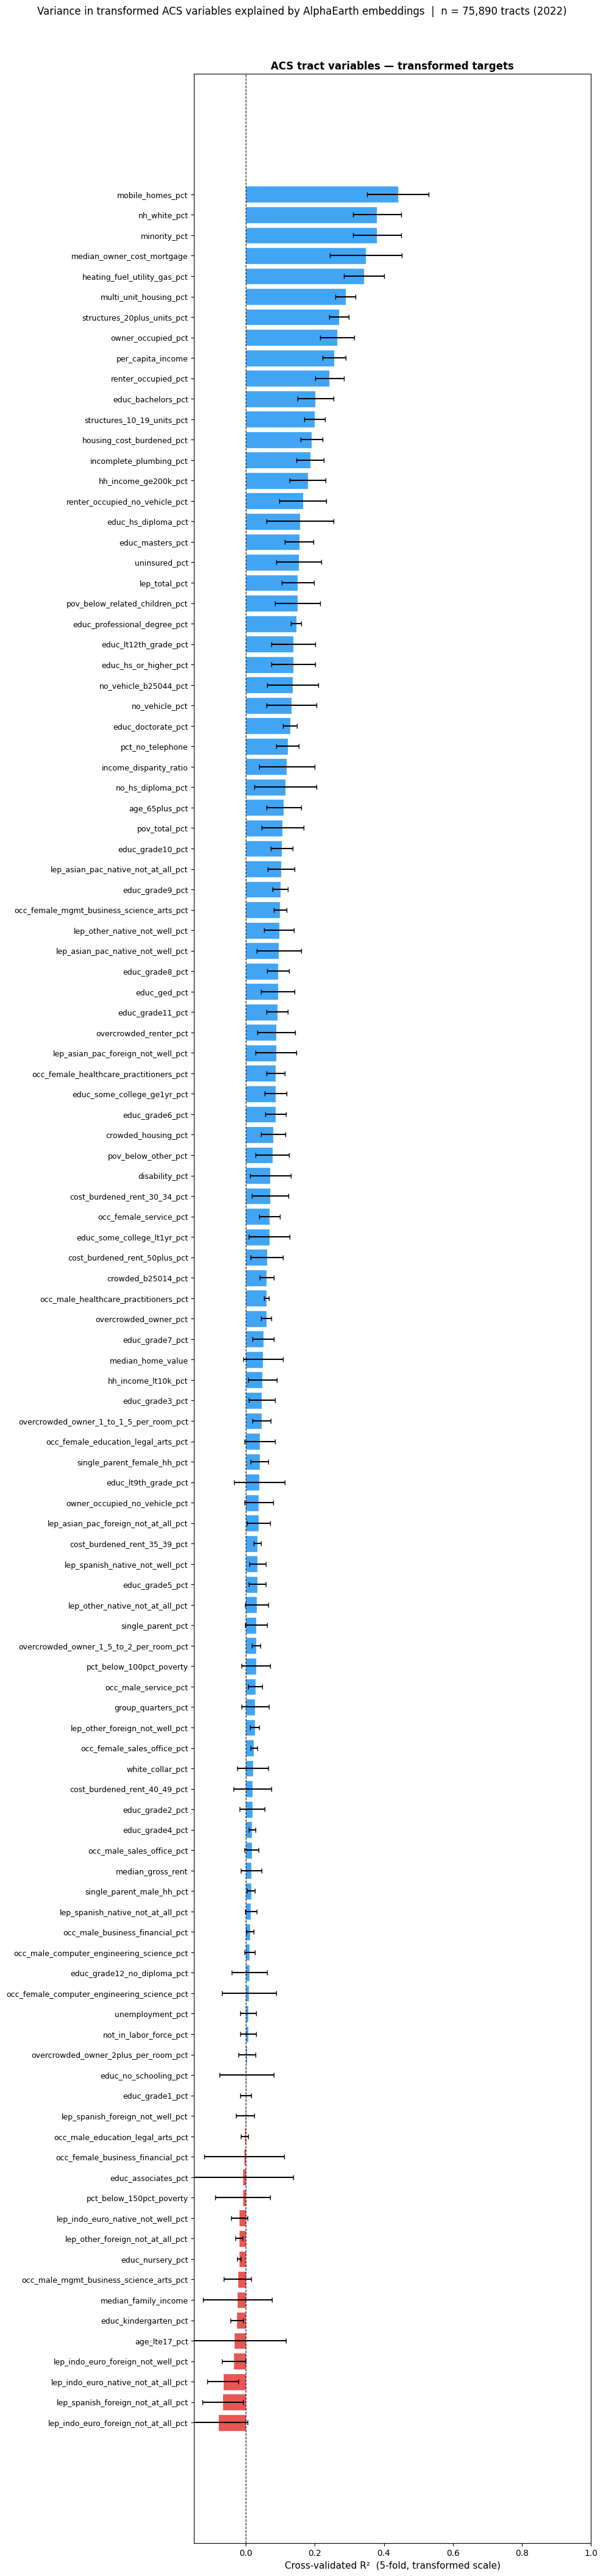

Done — 110 ACS variables evaluated (transformed)


group,variable,orig_var,transform,r2_mean,r2_std,indices
str,str,str,str,f64,f64,str
"""ACS""","""mobile_homes_pct__t""","""mobile_homes_pct""","""logit""",0.44065,0.088558,"""SVI"""
"""ACS""","""nh_white_pct__t""","""nh_white_pct""","""logit""",0.380418,0.069815,"""SVI"""
"""ACS""","""minority_pct__t""","""minority_pct""","""logit""",0.380418,0.069815,"""SVI"""
"""ACS""","""median_owner_cost_mortgage__t""","""median_owner_cost_mortgage""","""log1p""",0.348129,0.10458,"""ADI"""
"""ACS""","""heating_fuel_utility_gas_pct__…","""heating_fuel_utility_gas_pct""","""logit""",0.342704,0.058597,"""ADI"""
…,…,…,…,…,…,…
"""ACS""","""educ_bachelors_pct__t""","""educ_bachelors_pct""","""logit""",0.20188,0.051995,"""ADI"""
"""ACS""","""structures_10_19_units_pct__t""","""structures_10_19_units_pct""","""logit""",0.199188,0.029682,"""SVI"""
"""ACS""","""housing_cost_burdened_pct__t""","""housing_cost_burdened_pct""","""logit""",0.191111,0.031815,"""SVI"""


In [55]:
# ── Q1 transformed: bar chart ─────────────────────────────────────────────────
acs_t_results = results_t_df.filter(pl.col("group") == "ACS")
n_acs = len(acs_t_results)

fig, ax = plt.subplots(figsize=(10, max(8, 0.38 * n_acs)))
data_s = acs_t_results.sort("r2_mean")
labels  = [v.removesuffix("__t") for v in data_s["variable"].to_list()]
means   = data_s["r2_mean"].to_list()
stds    = data_s["r2_std"].to_list()
colors  = ["#2196F3" if v >= 0 else "#E53935" for v in means]
ax.barh(labels, means, xerr=stds, color=colors, capsize=3,
        alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Cross-validated R²  (5-fold, transformed scale)", fontsize=11)
ax.set_xlim(-0.15, 1.0)
ax.set_title("ACS tract variables — transformed targets", fontsize=12, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
plt.suptitle(
    f"Variance in transformed ACS variables explained by AlphaEarth embeddings  |  "
    f"n = {len(df):,} tracts (2022)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "r2_embeddings_transformed.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Done — {n_acs} ACS variables evaluated (transformed)")
acs_t_results.head(15)


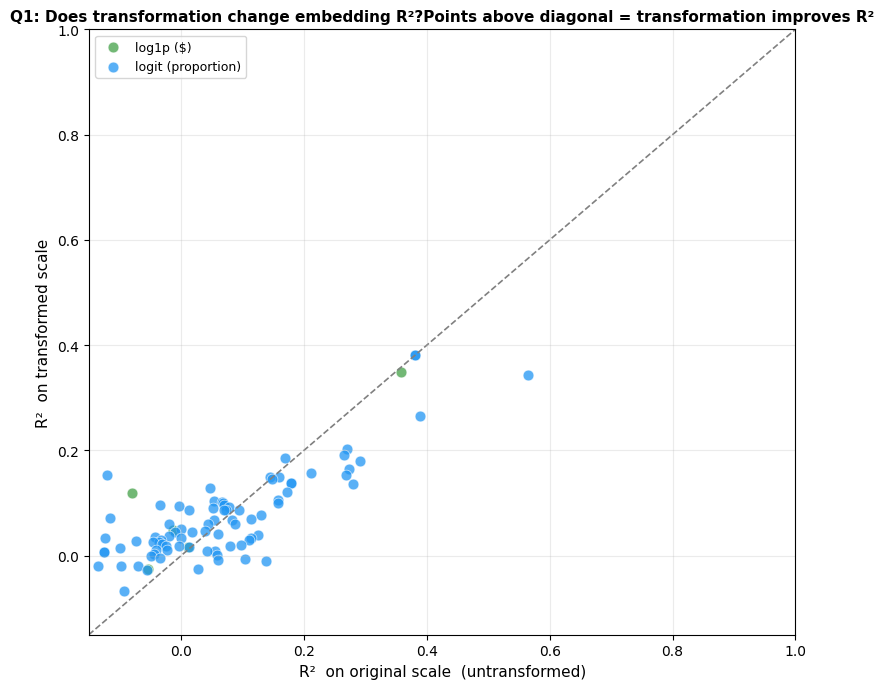

73/110 ACS variables have higher R² after transformation


In [67]:
# ── Q1 comparison: original vs transformed R² ─────────────────────────────────
_q1_orig_cache = OUTPUTS_DIR / "acs_correlations.csv"

if _q1_orig_cache.exists():
    orig_r2 = (
        pl.read_csv(_q1_orig_cache)
        .filter(pl.col("group") == "ACS")
        .select(["variable", "r2_mean"])
        .rename({"r2_mean": "r2_orig"})
    )
    cmp = (
        acs_t_results
        .select(["variable", "orig_var", "transform", "r2_mean"])
        .rename({"r2_mean": "r2_t"})
        .join(orig_r2.rename({"variable": "orig_var"}), on="orig_var", how="left")
        .to_pandas()
    )

    METHOD_COLOR = {"logit": "#2196F3", "sqrt": "#FF7043", "log1p": "#43A047", "none": "#9E9E9E"}
    fig, ax = plt.subplots(figsize=(8, 7))
    for method, grp in cmp.groupby("transform"):
        ax.scatter(
            grp["r2_orig"], grp["r2_t"],
            color=METHOD_COLOR.get(method, "#9E9E9E"),
            label=TRANSFORM_LABEL.get(method, method),
            alpha=0.75, s=60, edgecolors="white", linewidths=0.5,
        )
    lim = [-0.15, 1.0]
    ax.plot(lim, lim, color="grey", linewidth=1.2, linestyle="--", zorder=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("R²  on original scale  (untransformed)", fontsize=11)
    ax.set_ylabel("R²  on transformed scale", fontsize=11)
    ax.set_title("Q1: Does transformation change embedding R²?"
                 "Points above diagonal = transformation improves R²", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "r2_comparison_q1.png", dpi=150, bbox_inches="tight")
    plt.show()
    n_above = (cmp["r2_t"] > cmp["r2_orig"]).sum()
    print(f"{n_above}/{len(cmp)} ACS variables have higher R² after transformation")
else:
    print("Original acs_correlations.csv not found — run analyses.ipynb first to generate baseline.")
    acs_t_results.head(15)


## Q2: Embeddings vs. ReADI for predicting CDC PLACES health outcomes (logit-transformed targets)

Same design as Q2 in the original notebook (held-out states, 20%).  
PLACES prevalence measures are **logit-transformed** before fitting (bounded % → unbounded real line).  
R² is reported on the logit scale; a comparison scatter vs. untransformed R² is shown at the end.


In [57]:
FIPS_TO_ABBR = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT",
    "10":"DE","11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL",
    "18":"IN","19":"IA","20":"KS","21":"KY","22":"LA","23":"ME","24":"MD",
    "25":"MA","26":"MI","27":"MN","28":"MS","29":"MO","30":"MT","31":"NE",
    "32":"NV","33":"NH","34":"NJ","35":"NM","36":"NY","37":"NC","38":"ND",
    "39":"OH","40":"OK","41":"OR","42":"PA","44":"RI","45":"SC","46":"SD",
    "47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA","54":"WV",
    "55":"WI","56":"WY",
}

# --- Load ReADI ---
readi = (
    pl.read_csv(DATA_DIR / "ReADI_CT_2022.csv", infer_schema_length=5_000)
    .select(["GEOID", "ReADI_CT_NR"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
)

# --- Load SVI / SDI / ADI composites (2020) ---
sdvi = (
    pl.read_csv(DATA_DIR / "sdvi_ct_2020.csv", infer_schema_length=5_000, null_values=["NA"])
    .select(["GEOID", "SVI", "SDI", "ADI"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
)

df2 = (
    df.join(readi, on="tract_fips", how="inner")
      .join(sdvi, on="tract_fips", how="left")
      .with_columns(pl.col("tract_fips").str.slice(0, 2).alias("state_fips"))
)
print(df2.head(10))

# --- Define state holdout split (20% of states, seed=42) ---
all_states = sorted(df2["state_fips"].unique().to_list())
rng = np.random.default_rng(42)
holdout_states = set(rng.choice(all_states, size=max(1, round(0.2 * len(all_states))), replace=False).tolist())
train_states   = set(all_states) - holdout_states

df2_pd     = df2.to_pandas()

# Add logit-transformed PLACES columns to df2_pd
for _m in PLACES_MEASURES:
    _tc = f"{_m}__t"
    if _m in df2_pd.columns:
        df2_pd[_tc] = apply_transform(df2_pd[_m].to_numpy(dtype=float), "logit")
train_mask = df2_pd["state_fips"].isin(train_states).to_numpy()
test_mask  = df2_pd["state_fips"].isin(holdout_states).to_numpy()

READI_FEATS     = ["ReADI_CT_NR"]
SVI_FEATS       = ["SVI"]
SDI_FEATS       = ["SDI"]
ALL_INDEX_FEATS = READI_FEATS + SVI_FEATS + SDI_FEATS
COMBINED_FEATS  = ALL_INDEX_FEATS + FEATURE_COLS

holdout_abbrs = sorted(FIPS_TO_ABBR.get(s, s) for s in holdout_states)
print(f"Training states : {len(train_states)}  ({train_mask.sum():,} tracts)")
print(f"Held-out states : {len(holdout_states)}  ({test_mask.sum():,} tracts)")
print(f"Held-out states : {holdout_abbrs}")


shape: (10, 480)
┌─────────────┬───────────┬────────────┬────────────┬───┬──────────┬───────────┬──────┬────────────┐
│ tract_fips  ┆ A00_MEAN  ┆ A00_MEDIAN ┆ A00_MINIMU ┆ … ┆ SVI      ┆ SDI       ┆ ADI  ┆ state_fips │
│ ---         ┆ ---       ┆ ---        ┆ M          ┆   ┆ ---      ┆ ---       ┆ ---  ┆ ---        │
│ str         ┆ f64       ┆ f64        ┆ ---        ┆   ┆ f64      ┆ f64       ┆ i64  ┆ str        │
│             ┆           ┆            ┆ f64        ┆   ┆          ┆           ┆      ┆            │
╞═════════════╪═══════════╪════════════╪════════════╪═══╪══════════╪═══════════╪══════╪════════════╡
│ 01001020100 ┆ -0.117173 ┆ -0.113741  ┆ -0.199862  ┆ … ┆ null     ┆ null      ┆ null ┆ 01         │
│ 01001020200 ┆ -0.100756 ┆ -0.098424  ┆ -0.130165  ┆ … ┆ null     ┆ null      ┆ null ┆ 01         │
│ 01001020300 ┆ -0.121377 ┆ -0.098424  ┆ -0.186082  ┆ … ┆ null     ┆ null      ┆ null ┆ 01         │
│ 01001020400 ┆ -0.108158 ┆ -0.103406  ┆ -0.172795  ┆ … ┆ null     ┆ null 

In [58]:
%%capture
def fit_eval(feat_cols: list[str], y: np.ndarray, train: np.ndarray, test: np.ndarray) -> float:
    """Fit LightGBM on train rows, return R² on test rows."""
    X_tr = df2_pd.loc[train, feat_cols].to_numpy(dtype=float)
    X_te = df2_pd.loc[test,  feat_cols].to_numpy(dtype=float)
    model = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, random_state=42, verbosity=-1,
    )
    model.fit(X_tr, y[train])
    return float(r2_score(y[test], model.predict(X_te)))


_q2t_cache = OUTPUTS_DIR / "places_reg_transformed.csv"

if USE_CACHED and _q2t_cache.exists():
    results_q2t_df = pl.read_csv(_q2t_cache)
else:
    results_q2t = []
    for col_t in PLACES_VARS_T:
        col_orig = col_t.removesuffix("__t")
        if col_t not in df2_pd.columns:
            continue
        y = df2_pd[col_t].to_numpy(dtype=float)
        valid       = np.isfinite(y)
        train_valid = train_mask & valid
        test_valid  = test_mask  & valid
        if train_valid.sum() < 100 or test_valid.sum() < 50:
            continue

        for feat_cols, model_name in [
            (READI_FEATS,     "ReADI"),
            (SVI_FEATS,       "SVI"),
            (SDI_FEATS,       "SDI"),
            (ALL_INDEX_FEATS, "All indices"),
            (FEATURE_COLS,    "Embeddings"),
            (COMBINED_FEATS,  "All indices + Embeddings"),
        ]:
            X_tr = df2_pd.loc[train_valid, feat_cols].to_numpy(dtype=float)
            X_te = df2_pd.loc[test_valid,  feat_cols].to_numpy(dtype=float)
            m = lgb.LGBMRegressor(
                n_estimators=300, learning_rate=0.05, num_leaves=31,
                min_child_samples=20, random_state=42, verbosity=-1,
            )
            m.fit(X_tr, y[train_valid])
            r2 = float(r2_score(y[test_valid], m.predict(X_te)))
            results_q2t.append({
                "outcome": col_orig, "model": model_name, "r2": r2,
                "n_train": int(train_valid.sum()), "n_test": int(test_valid.sum()),
            })

    results_q2t_df = pl.DataFrame(results_q2t)
    results_q2t_df.write_csv(_q2t_cache)


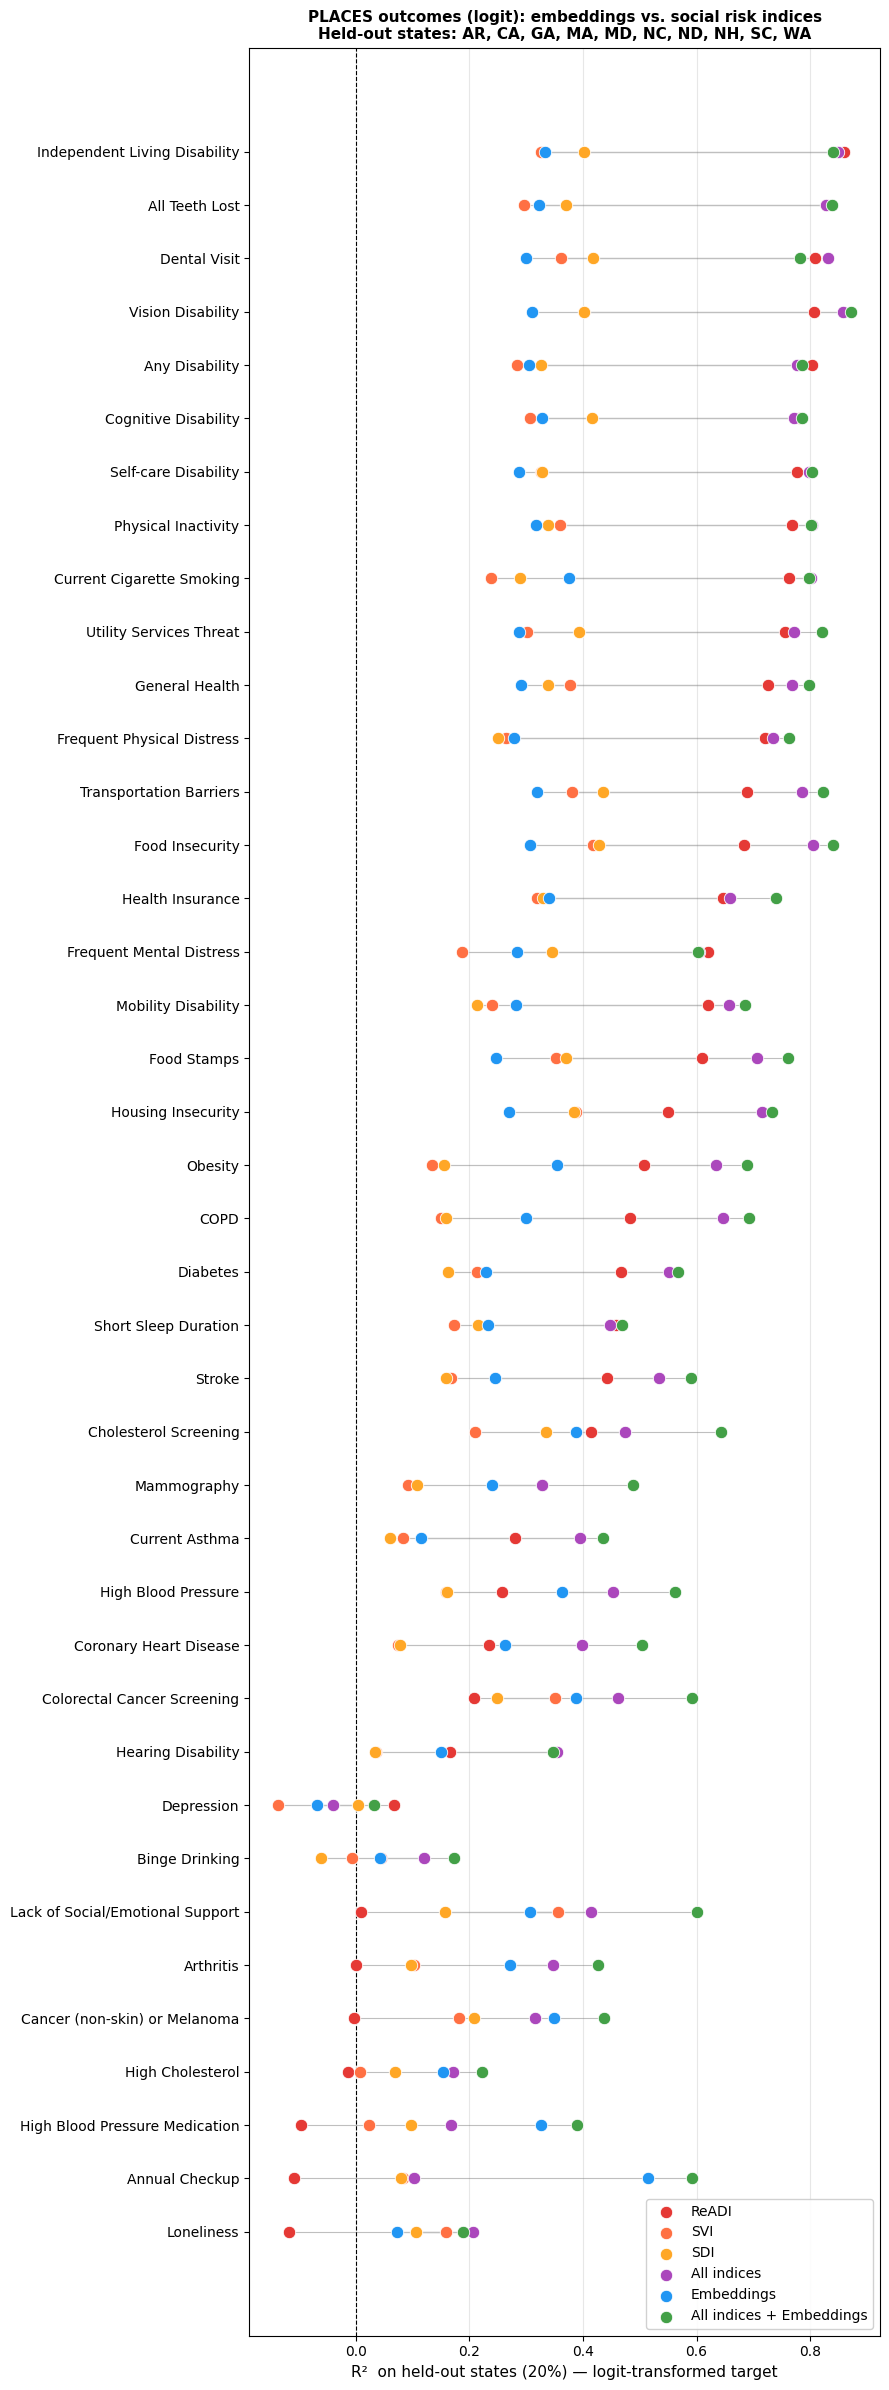

outcome,ReADI,SVI,SDI,All indices,Embeddings,All indices + Embeddings
str,f64,f64,f64,f64,f64,f64
"""INDEPLIVE""",0.859254,0.325669,0.401884,0.849733,0.332516,0.83958
"""TEETHLOST""",0.827753,0.296951,0.371151,0.827587,0.322084,0.838095
"""DENTAL""",0.808914,0.361922,0.416968,0.83187,0.299904,0.781499
"""VISION""",0.805898,0.401915,0.401501,0.857202,0.309609,0.872416
"""DISABILITY""",0.803917,0.283296,0.325841,0.777644,0.305848,0.785013
…,…,…,…,…,…,…
"""CANCER""",-0.002179,0.182676,0.208891,0.31517,0.349347,0.437734
"""HIGHCHOL""",-0.014073,0.007573,0.069126,0.171567,0.154153,0.221907
"""BPMED""",-0.0969,0.023883,0.097893,0.167537,0.325777,0.389112


In [60]:
MODEL_ORDER  = ["ReADI", "SVI", "SDI", "All indices", "Embeddings", "All indices + Embeddings"]
MODEL_COLORS = {
    "ReADI":                    "#E53935",
    "SVI":                      "#FF7043",
    "SDI":                      "#FFA726",
    "All indices":              "#AB47BC",
    "Embeddings":               "#2196F3",
    "All indices + Embeddings": "#43A047",
}

readi_r2_t = (
    results_q2t_df.filter(pl.col("model") == "ReADI")
    .sort("r2")
    .select("outcome")
    .to_series().to_list()
)
readi_r2_labels_t = [PLACES_LABELS.get(o, o) for o in readi_r2_t]

fig, ax = plt.subplots(figsize=(9, max(4, 0.6 * len(readi_r2_t))))
for model_name in MODEL_ORDER:
    sub = (
        results_q2t_df.filter(pl.col("model") == model_name)
        .with_columns(pl.col("outcome").cast(pl.Enum(readi_r2_t)))
        .sort("outcome")
    )
    ys     = [readi_r2_t.index(o) for o in sub["outcome"].to_list()]
    r2vals = sub["r2"].to_list()
    ax.scatter(r2vals, ys, color=MODEL_COLORS[model_name], label=model_name,
               zorder=3, s=80, edgecolors="white", linewidths=0.6)

for i, outcome in enumerate(readi_r2_t):
    row = results_q2t_df.filter(pl.col("outcome") == outcome).sort("model")
    r2s = {r["model"]: r["r2"] for r in row.iter_rows(named=True)}
    xs  = [r2s.get(m, np.nan) for m in MODEL_ORDER]
    ax.plot(xs, [i] * len(MODEL_ORDER), color="grey", linewidth=0.8, zorder=2, alpha=0.5)

ax.set_yticks(range(len(readi_r2_t)))
ax.set_yticklabels(readi_r2_labels_t, fontsize=10)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("R²  on held-out states (20%) — logit-transformed target", fontsize=11)
ax.set_title(
    f"PLACES outcomes (logit): embeddings vs. social risk indices\n"
    f"Held-out states: {', '.join(holdout_abbrs)}",
    fontsize=11, fontweight="bold",
)
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "places_reg_transformed.png", dpi=150, bbox_inches="tight")
plt.show()
results_q2t_df.pivot(on="model", index="outcome", values="r2").sort("ReADI", descending=True)


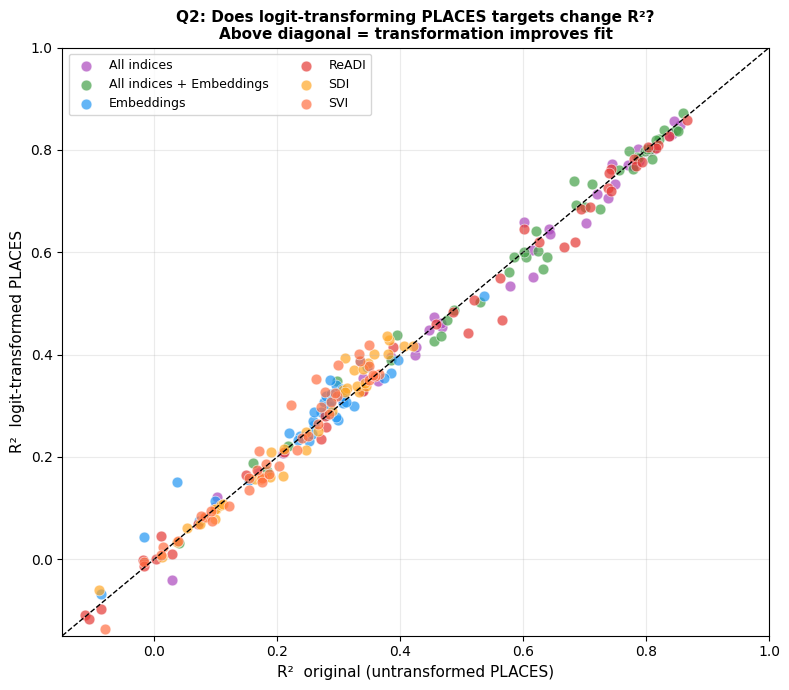

In [68]:
_q2_orig = OUTPUTS_DIR / "places_reg.csv"
if _q2_orig.exists():
    orig_q2 = pl.read_csv(_q2_orig).rename({"r2": "r2_orig"})
    cmp_q2  = (
        results_q2t_df
        .rename({"r2": "r2_t"})
        .join(orig_q2.select(["outcome", "model", "r2_orig"]), on=["outcome", "model"], how="left")
        .to_pandas()
    )
    fig, ax = plt.subplots(figsize=(8, 7))
    for model_name, grp in cmp_q2.groupby("model"):
        ax.scatter(grp["r2_orig"], grp["r2_t"],
                   color=MODEL_COLORS.get(model_name, "#9E9E9E"),
                   label=model_name, alpha=0.7, s=60,
                   edgecolors="white", linewidths=0.5)
    lim = [-0.15, 1.0]
    ax.plot(lim, lim, "k--", linewidth=1, zorder=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("R²  original (untransformed PLACES)", fontsize=11)
    ax.set_ylabel("R²  logit-transformed PLACES", fontsize=11)
    ax.set_title("Q2: Does logit-transforming PLACES targets change R²?\n"
                 "Above diagonal = transformation improves fit", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, ncol=2, loc="upper left")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "places_reg_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Original places_reg.csv not found — run analyses.ipynb first.")


## Q3: What amount of the variation in tract-level CDC PLACES data that cannot be explained by social risk indices *can* be explained by embeddings?
First, we'll use LightGBM to allow for non-linear relationships between ReADI and CDC PLACES data. Second, we'll collect those residuals and use them as the outcome of a LightGBM analysis with embeddings as the exposure of interest.

Note that this is different from conventional "partialing out", since we do not assume a linear relationship. By allowing a non-linear relationship between ReADI and tract-level health outcomes, then performing that regression first, we produce a *conservative* estimate of the residual that can be explained by embeddings. 

In [62]:
%%capture
def residual_r2(
    col: str,
    col_t: str,
    y: np.ndarray,
    train_valid: np.ndarray,
    test_valid: np.ndarray,
    index_feats: list[str],
    index_name: str,
) -> dict:
    """Two-stage nonlinear residual analysis on logit-transformed PLACES target."""
    lgbm_kw = dict(n_estimators=300, learning_rate=0.05, num_leaves=31,
                   min_child_samples=20, random_state=42, verbosity=-1)

    X_r_tr = df2_pd.loc[train_valid, index_feats].to_numpy(dtype=float)
    X_r_te = df2_pd.loc[test_valid,  index_feats].to_numpy(dtype=float)
    m1 = lgb.LGBMRegressor(**lgbm_kw)
    m1.fit(X_r_tr, y[train_valid])
    resid_train = y[train_valid] - m1.predict(X_r_tr)
    resid_test  = y[test_valid]  - m1.predict(X_r_te)
    r2_s1 = float(r2_score(y[test_valid], m1.predict(X_r_te)))

    X_e_tr = df2_pd.loc[train_valid, FEATURE_COLS].to_numpy(dtype=float)
    X_e_te = df2_pd.loc[test_valid,  FEATURE_COLS].to_numpy(dtype=float)
    m2 = lgb.LGBMRegressor(**lgbm_kw)
    m2.fit(X_e_tr, resid_train)
    r2_resid = float(r2_score(resid_test, m2.predict(X_e_te)))
    additional_var = max(0.0, r2_resid) * max(0.0, 1.0 - r2_s1)

    return {
        "index": index_name, "outcome": col,
        "r2_index": r2_s1, "r2_residual": r2_resid,
        "additional_var": additional_var,
        "n_train": int(train_valid.sum()), "n_test": int(test_valid.sum()),
    }


_q3t_cache = OUTPUTS_DIR / "places_residual_by_index_transformed.csv"

if USE_CACHED and _q3t_cache.exists():
    results_q3t_df = pl.read_csv(_q3t_cache)
else:
    results_q3t = []
    for col, col_t in zip(PLACES_MEASURES, PLACES_VARS_T):
        if col_t not in df2_pd.columns:
            continue
        y = df2_pd[col_t].to_numpy(dtype=float)
        valid       = np.isfinite(y)
        train_valid = train_mask & valid
        test_valid  = test_mask  & valid
        if train_valid.sum() < 100 or test_valid.sum() < 50:
            continue
        for index_feats, index_name in [
            (READI_FEATS, "ReADI"),
            (SVI_FEATS,   "SVI"),
            (SDI_FEATS,   "SDI"),
        ]:
            results_q3t.append(residual_r2(col, col_t, y, train_valid, test_valid, index_feats, index_name))

    results_q3t_df = pl.DataFrame(results_q3t).sort(["index", "r2_residual"], descending=[False, True])
    results_q3t_df.write_csv(_q3t_cache)


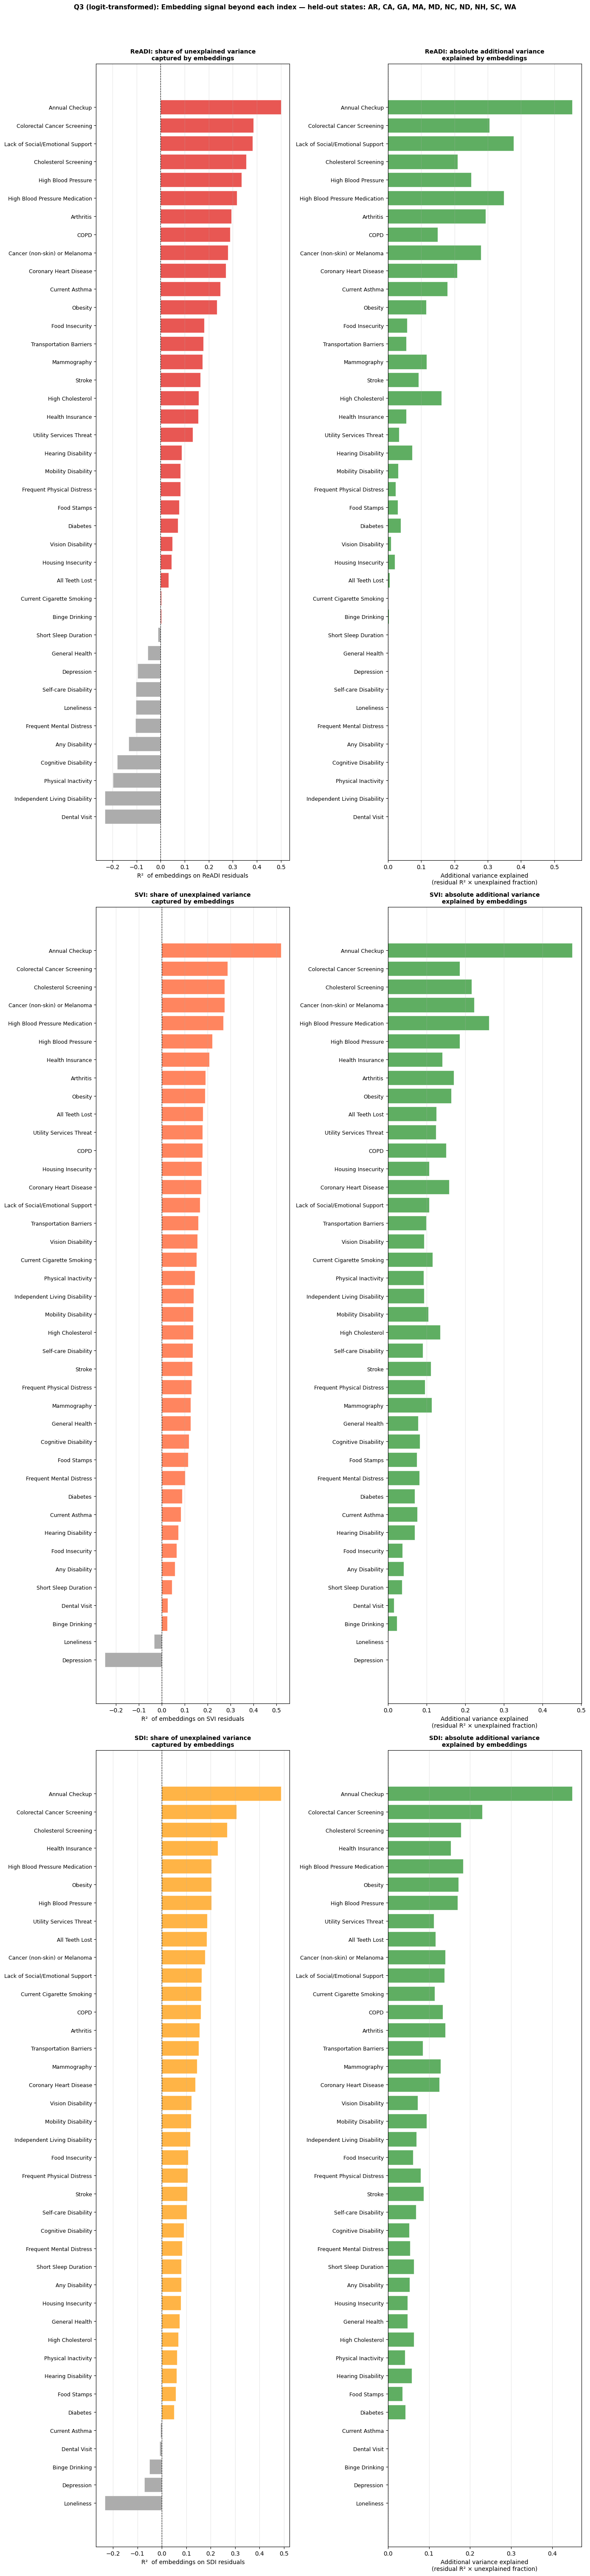

Done — 40 outcomes × 3 indices


index,outcome,r2_index,r2_residual,additional_var,n_train,n_test
str,str,f64,f64,f64,i64,i64
"""ReADI""","""CHECKUP""",-0.108537,0.499611,0.553837,50745,20664
"""ReADI""","""COLON_SCREEN""",0.208904,0.385777,0.305187,55214,20663
"""ReADI""","""EMOTIONSPT""",0.010051,0.381627,0.377791,34653,18941
"""ReADI""","""CHOLSCREEN""",0.413795,0.356613,0.209048,50745,20664
"""ReADI""","""BPHIGH""",0.258482,0.337144,0.249998,50745,20664
…,…,…,…,…,…,…
"""SVI""","""SLEEP""",0.173905,0.044398,0.036677,55215,20664
"""SVI""","""DENTAL""",0.361922,0.024955,0.015923,55215,20664
"""SVI""","""BINGE""",-0.005873,0.022766,0.0229,50745,20664


In [63]:
INDEX_NAMES  = ["ReADI", "SVI", "SDI"]
INDEX_COLORS = {"ReADI": "#E53935", "SVI": "#FF7043", "SDI": "#FFA726"}

readi_order = (
    results_q3t_df.filter(pl.col("index") == "ReADI")
    .sort("r2_residual")["outcome"].to_list()
)
svi_order = (
    results_q3t_df.filter(pl.col("index") == "SVI")
    .sort("r2_residual")["outcome"].to_list()
)
sdi_order = (
    results_q3t_df.filter(pl.col("index") == "SDI")
    .sort("r2_residual")["outcome"].to_list()
)

INDEX_ORDERS = [readi_order, svi_order, sdi_order]

fig, axes = plt.subplots(
    len(INDEX_NAMES), 2,
    figsize=(14, max(6, 0.5 * len(readi_order)) * len(INDEX_NAMES)),
    gridspec_kw={"width_ratios": [1, 1]},
)

for row_i, idx_name in enumerate(INDEX_NAMES):
    order          = INDEX_ORDERS[row_i]
    y_pos          = np.arange(len(order))
    outcome_labels = [PLACES_LABELS.get(o, o) for o in order]

    plot_df = (
        results_q3t_df.filter(pl.col("index") == idx_name)
        .with_columns(pl.col("outcome").cast(pl.Enum(order)))
        .sort("outcome")
    )
    r2_resid   = plot_df["r2_residual"].to_list()
    additional = plot_df["additional_var"].to_list()
    color      = INDEX_COLORS[idx_name]

    ax = axes[row_i, 0]
    bar_colors = [color if v >= 0 else "#9E9E9E" for v in r2_resid]
    ax.barh(y_pos, r2_resid, color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"R²  of embeddings on {idx_name} residuals", fontsize=10)
    ax.set_title(f"{idx_name}: share of unexplained variance\ncaptured by embeddings",
                 fontsize=10, fontweight="bold")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(outcome_labels, fontsize=9)
    ax.grid(axis="x", alpha=0.3)

    ax = axes[row_i, 1]
    ax.barh(y_pos, additional, color="#43A047", alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Additional variance explained\n(residual R² × unexplained fraction)", fontsize=10)
    ax.set_title(f"{idx_name}: absolute additional variance\nexplained by embeddings",
                 fontsize=10, fontweight="bold")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(outcome_labels, fontsize=9)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    f"Q3 (logit-transformed): Embedding signal beyond each index — held-out states: {', '.join(holdout_abbrs)}",
    fontsize=11, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "places_residual_by_index_transformed.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Done — {len(readi_order)} outcomes × {len(INDEX_NAMES)} indices")
results_q3t_df


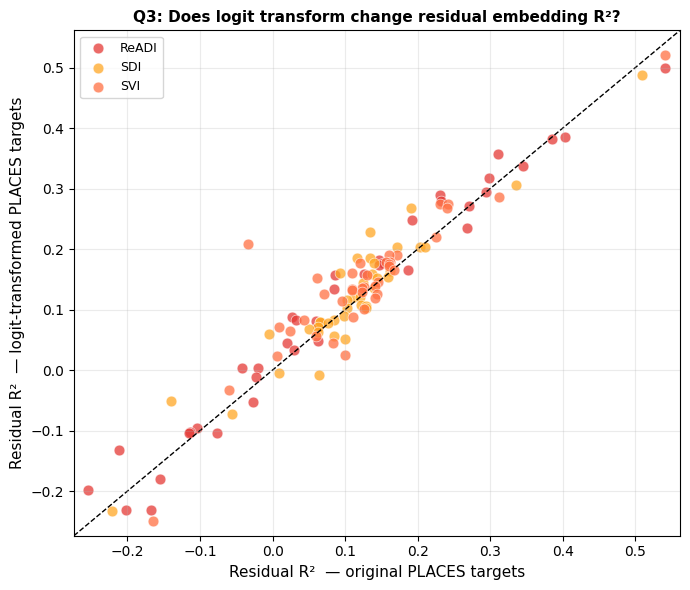

In [69]:
_q3_orig = OUTPUTS_DIR / "places_residual_by_index.csv"
if _q3_orig.exists():
    orig_q3 = (
        pl.read_csv(_q3_orig)
        .select(["index", "outcome", "r2_residual"])
        .rename({"r2_residual": "r2_resid_orig"})
    )
    cmp_q3 = (
        results_q3t_df
        .select(["index", "outcome", "r2_residual"])
        .rename({"r2_residual": "r2_resid_t"})
        .join(orig_q3, on=["index", "outcome"], how="left")
        .to_pandas()
    )
    INDEX_COLORS = {"ReADI": "#E53935", "SVI": "#FF7043", "SDI": "#FFA726"}
    fig, ax = plt.subplots(figsize=(7, 6))
    for idx_name, grp in cmp_q3.groupby("index"):
        ax.scatter(grp["r2_resid_orig"], grp["r2_resid_t"],
                   color=INDEX_COLORS.get(idx_name, "#9E9E9E"),
                   label=idx_name, alpha=0.75, s=60,
                   edgecolors="white", linewidths=0.5)
    lim_lo = min(cmp_q3[["r2_resid_orig","r2_resid_t"]].min()) - 0.02
    lim_hi = max(cmp_q3[["r2_resid_orig","r2_resid_t"]].max()) + 0.02
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", linewidth=1, zorder=1)
    ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
    ax.set_xlabel("Residual R²  — original PLACES targets", fontsize=11)
    ax.set_ylabel("Residual R²  — logit-transformed PLACES targets", fontsize=11)
    ax.set_title("Q3: Does logit transform change residual embedding R²?", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "q3_residual_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Original places_residual_by_index.csv not found — run analyses.ipynb first.")


## Q4: How much heterogeneity is there in embedding performance across states? Across rural vs urban areas? 
For the first question, perform statewise regressions with ReADI only and embeddings only. Average R² across PLACES outcomes and use a scatterplot to compare average ReADI correlation versus average embedding correlation by state. For the second question, separate tracts into deciles by area. Perform decile-wise regressions for each of the 40 outcomes by ReADI only and by embeddings only. Average R² within deciles for each representation type, and plot using a scatter plot.


In [64]:
%%capture
_q4st_cache = OUTPUTS_DIR / "q4_state_transformed.csv"
_q4dt_cache = OUTPUTS_DIR / "q4_decile_transformed.csv"

if USE_CACHED and _q4st_cache.exists() and _q4dt_cache.exists():
    results_q4t_state_df  = pl.read_csv(_q4st_cache)
    results_q4t_decile_df = pl.read_csv(_q4dt_cache)
else:
    X_readi_all = df2_pd[READI_FEATS].to_numpy(dtype=float)
    X_svi_all   = df2_pd[SVI_FEATS].to_numpy(dtype=float)
    X_sdi_all   = df2_pd[SDI_FEATS].to_numpy(dtype=float)
    X_emb_all   = df2_pd[FEATURE_COLS].to_numpy(dtype=float)

    def cv_r2_subset(X: np.ndarray, y: np.ndarray, n_splits: int = 2) -> float:
        if len(y) < n_splits * 5:
            return np.nan
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, va in kf.split(X):
            m = lgb.LGBMRegressor(
                n_estimators=30, learning_rate=0.15, num_leaves=16,
                min_child_samples=20, random_state=42, verbosity=-1,
            )
            m.fit(X[tr], y[tr])
            scores.append(r2_score(y[va], m.predict(X[va])))
        return float(np.nanmean(scores))

    # ── Q4a: State-wise (transformed targets) ─────────────────────────────────
    results_q4t_state = []
    for state_fips in sorted(df2_pd["state_fips"].unique()):
        state_mask = (df2_pd["state_fips"] == state_fips).to_numpy()
        if state_mask.sum() < 50:
            continue
        state_abbr = FIPS_TO_ABBR.get(state_fips, state_fips)
        r2s_readi, r2s_svi, r2s_sdi, r2s_emb = [], [], [], []
        for col, col_t in zip(PLACES_MEASURES, PLACES_VARS_T):
            if col_t not in df2_pd.columns:
                continue
            valid = state_mask & np.isfinite(df2_pd[col_t].to_numpy(dtype=float))
            if valid.sum() < 50:
                continue
            idx = np.where(valid)[0]
            y   = df2_pd[col_t].iloc[idx].to_numpy(dtype=float)
            r2s_readi.append(cv_r2_subset(X_readi_all[idx], y))
            r2s_svi.append(cv_r2_subset(X_svi_all[idx], y))
            r2s_sdi.append(cv_r2_subset(X_sdi_all[idx], y))
            r2s_emb.append(cv_r2_subset(X_emb_all[idx], y))
        if r2s_readi:
            results_q4t_state.append({
                "state": state_abbr,
                "r2_readi": float(np.nanmean(r2s_readi)),
                "r2_svi":   float(np.nanmean(r2s_svi)),
                "r2_sdi":   float(np.nanmean(r2s_sdi)),
                "r2_emb":   float(np.nanmean(r2s_emb)),
                "n_outcomes": len(r2s_readi),
                "n_tracts":   int(state_mask.sum()),
            })

    results_q4t_state_df = pl.DataFrame(results_q4t_state)
    results_q4t_state_df.write_csv(_q4st_cache)

    # ── Q4b: Tract-size deciles (transformed targets) ─────────────────────────
    aland = df2_pd["ALAND"].to_numpy(dtype=float)
    _edges = np.nanpercentile(aland, np.linspace(0, 100, 11))
    _edges[0] -= 1
    decile_labels = np.searchsorted(_edges[1:-1], aland)

    results_q4t_decile = []
    for dec in range(10):
        dec_mask = (decile_labels == dec)
        if dec_mask.sum() < 50:
            continue
        r2s_readi, r2s_svi, r2s_sdi, r2s_emb = [], [], [], []
        for col, col_t in zip(PLACES_MEASURES, PLACES_VARS_T):
            if col_t not in df2_pd.columns:
                continue
            valid = dec_mask & np.isfinite(df2_pd[col_t].to_numpy(dtype=float))
            if valid.sum() < 50:
                continue
            idx = np.where(valid)[0]
            y   = df2_pd[col_t].iloc[idx].to_numpy(dtype=float)
            r2s_readi.append(cv_r2_subset(X_readi_all[idx], y))
            r2s_svi.append(cv_r2_subset(X_svi_all[idx], y))
            r2s_sdi.append(cv_r2_subset(X_sdi_all[idx], y))
            r2s_emb.append(cv_r2_subset(X_emb_all[idx], y))
        if r2s_readi:
            results_q4t_decile.append({
                "decile":           dec + 1,
                "median_aland_km2": float(np.median(aland[dec_mask]) / 1e6),
                "r2_readi":         float(np.nanmean(r2s_readi)),
                "r2_svi":           float(np.nanmean(r2s_svi)),
                "r2_sdi":           float(np.nanmean(r2s_sdi)),
                "r2_emb":           float(np.nanmean(r2s_emb)),
                "n_tracts":         int(dec_mask.sum()),
            })

    results_q4t_decile_df = pl.DataFrame(results_q4t_decile)
    results_q4t_decile_df.write_csv(_q4dt_cache)


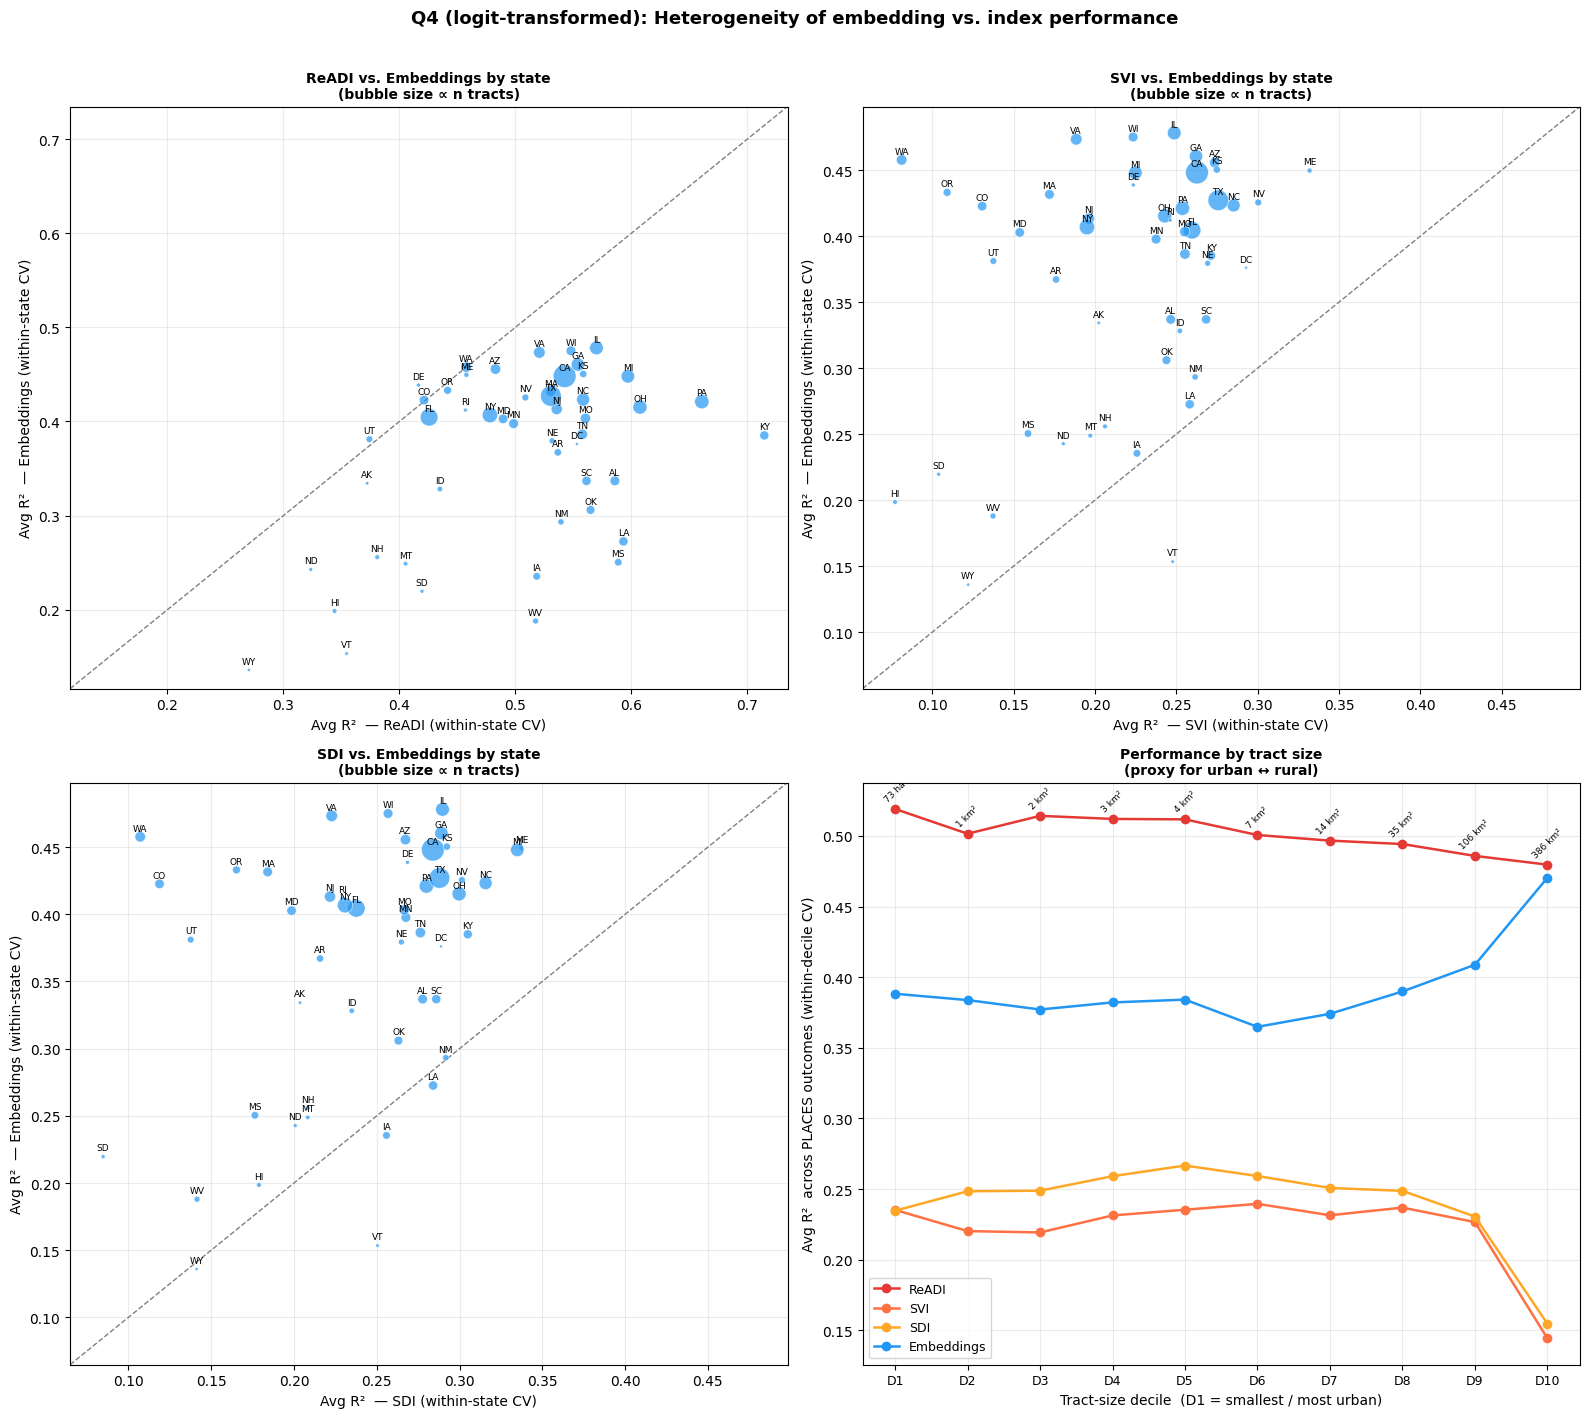

State results:


state,r2_readi,r2_svi,r2_sdi,r2_emb,n_outcomes,n_tracts
str,f64,f64,f64,f64,i64,i64
"""IL""",0.569844,0.248705,0.289692,0.47807,40,2925
"""WI""",0.547857,0.223452,0.256825,0.475019,40,1465
"""VA""",0.520593,0.188481,0.222778,0.473291,40,2090
"""GA""",0.553766,0.262111,0.289026,0.460392,40,2736
"""WA""",0.457599,0.081184,0.107156,0.457687,33,1723
…,…,…,…,…,…,…
"""SD""",0.419426,0.10394,0.084745,0.219631,33,242
"""HI""",0.344029,0.077158,0.178825,0.198554,40,338
"""WV""",0.517372,0.137344,0.14144,0.187939,40,543



Decile results:


decile,median_aland_km2,r2_readi,r2_svi,r2_sdi,r2_emb,n_tracts
i64,f64,f64,f64,f64,f64,i64
1,0.731027,0.519102,0.235254,0.234713,0.388289,7588
2,1.371883,0.501586,0.220261,0.248466,0.383813,7588
3,2.051565,0.514247,0.219312,0.248866,0.377139,7588
4,2.821702,0.512082,0.231343,0.259152,0.382166,7588
5,4.17829,0.511757,0.235396,0.266677,0.384136,7588
6,6.757201,0.500683,0.239556,0.259247,0.364872,7587
7,13.521546,0.496715,0.231467,0.250822,0.374093,7588
8,34.706583,0.494295,0.23689,0.248747,0.389911,7588
9,105.730054,0.485898,0.226648,0.230575,0.40881,7588


In [65]:
s_df = results_q4t_state_df.to_pandas()
d_df = results_q4t_decile_df.sort("decile").to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# ── Helper: state scatter panel ───────────────────────────────────────────────
def state_scatter(ax, index_col, index_label, index_color):
    ax.scatter(s_df[index_col], s_df["r2_emb"],
               s=s_df["n_tracts"] / 30, color="#2196F3",
               alpha=0.7, edgecolors="white", linewidths=0.5, zorder=3)
    for _, row in s_df.iterrows():
        ax.annotate(row["state"], (row[index_col], row["r2_emb"]),
                    fontsize=6.5, ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points")
    lim = [min(s_df[index_col].min(), s_df["r2_emb"].min()) - 0.02,
           max(s_df[index_col].max(), s_df["r2_emb"].max()) + 0.02]
    ax.plot(lim, lim, color="grey", linewidth=1, linestyle="--", zorder=2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Avg R²  — {index_label} (within-state CV)", fontsize=10)
    ax.set_ylabel("Avg R²  — Embeddings (within-state CV)", fontsize=10)
    ax.set_title(f"{index_label} vs. Embeddings by state\n(bubble size ∝ n tracts)",
                 fontsize=10, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.grid(alpha=0.25)

state_scatter(axes[0, 0], "r2_readi", "ReADI", "#E53935")
state_scatter(axes[0, 1], "r2_svi",   "SVI",   "#FF7043")
state_scatter(axes[1, 0], "r2_sdi",   "SDI",   "#FFA726")

# ── Panel 4: Tract-size decile line plot (all 4 lines) ───────────────────────
ax = axes[1, 1]
ax.plot(d_df["decile"], d_df["r2_readi"],
        color="#E53935", marker="o", linewidth=1.8, markersize=6, label="ReADI")
ax.plot(d_df["decile"], d_df["r2_svi"],
        color="#FF7043", marker="o", linewidth=1.8, markersize=6, label="SVI")
ax.plot(d_df["decile"], d_df["r2_sdi"],
        color="#FFA726", marker="o", linewidth=1.8, markersize=6, label="SDI")
ax.plot(d_df["decile"], d_df["r2_emb"],
        color="#2196F3", marker="o", linewidth=1.8, markersize=6, label="Embeddings")

for _, row in d_df.iterrows():
    area_str = (f"{row['median_aland_km2']:.0f} km²"
                if row["median_aland_km2"] >= 1
                else f"{row['median_aland_km2']*100:.0f} ha")
    top_r2 = max(row["r2_readi"], row["r2_svi"], row["r2_sdi"], row["r2_emb"])
    ax.annotate(area_str, (row["decile"], top_r2),
                fontsize=6.5, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points", rotation=45)

ax.set_xticks(d_df["decile"])
ax.set_xticklabels([f"D{d}" for d in d_df["decile"]], fontsize=9)
ax.set_xlabel("Tract-size decile  (D1 = smallest / most urban)", fontsize=10)
ax.set_ylabel("Avg R²  across PLACES outcomes (within-decile CV)", fontsize=10)
ax.set_title("Performance by tract size\n(proxy for urban ↔ rural)", fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.suptitle("Q4 (logit-transformed): Heterogeneity of embedding vs. index performance",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q4_heterogeneity_transformed.png", dpi=150, bbox_inches="tight")
plt.show()

print("State results:")
display(results_q4t_state_df.sort("r2_emb", descending=True))
print("\nDecile results:")
display(results_q4t_decile_df)


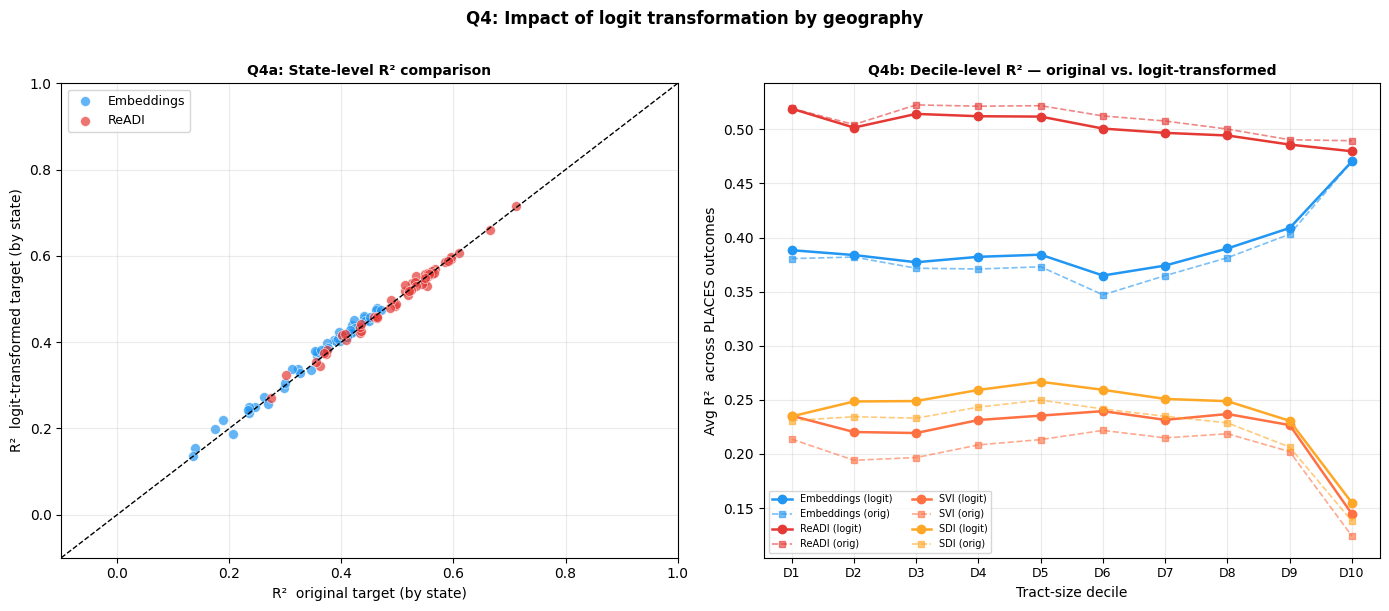

In [70]:
_q4s_orig = OUTPUTS_DIR / "q4_state.csv"
_q4d_orig = OUTPUTS_DIR / "q4_decile.csv"

if _q4s_orig.exists() and _q4d_orig.exists():
    orig_s = pl.read_csv(_q4s_orig).select(["state", "r2_readi", "r2_svi", "r2_sdi", "r2_emb"])
    cmp_s  = (
        results_q4t_state_df
        .select(["state", "r2_readi", "r2_svi", "r2_sdi", "r2_emb"])
        .join(orig_s, on="state", suffix="_orig")
        .to_pandas()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for model_col, color, label in [
        ("r2_emb", "#2196F3", "Embeddings"),
        ("r2_readi", "#E53935", "ReADI"),
    ]:
        axes[0].scatter(cmp_s[f"{model_col}_orig"], cmp_s[model_col],
                        color=color, label=label, alpha=0.7, s=50,
                        edgecolors="white", linewidths=0.5)
    lim = [-0.1, 1.0]
    axes[0].plot(lim, lim, "k--", linewidth=1)
    axes[0].set_xlim(lim); axes[0].set_ylim(lim)
    axes[0].set_xlabel("R²  original target (by state)", fontsize=10)
    axes[0].set_ylabel("R²  logit-transformed target (by state)", fontsize=10)
    axes[0].set_title("Q4a: State-level R² comparison", fontsize=10, fontweight="bold")
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25)

    orig_d = pl.read_csv(_q4d_orig).select(["decile", "r2_readi", "r2_svi", "r2_sdi", "r2_emb"])
    cmp_d  = (
        results_q4t_decile_df
        .select(["decile", "r2_readi", "r2_svi", "r2_sdi", "r2_emb"])
        .join(orig_d, on="decile", suffix="_orig")
        .sort("decile")
        .to_pandas()
    )
    for model_col, color, label in [
        ("r2_emb", "#2196F3", "Embeddings"),
        ("r2_readi", "#E53935", "ReADI"),
        ("r2_svi", "#FF7043", "SVI"),
        ("r2_sdi", "#FFA726", "SDI"),
    ]:
        axes[1].plot(cmp_d["decile"], cmp_d[model_col],       color=color, marker="o",
                     linewidth=1.8, markersize=6, label=f"{label} (logit)", linestyle="-")
        axes[1].plot(cmp_d["decile"], cmp_d[f"{model_col}_orig"], color=color, marker="s",
                     linewidth=1.2, markersize=5, label=f"{label} (orig)", linestyle="--", alpha=0.6)
    axes[1].set_xticks(cmp_d["decile"])
    axes[1].set_xticklabels([f"D{d}" for d in cmp_d["decile"]], fontsize=9)
    axes[1].set_xlabel("Tract-size decile", fontsize=10)
    axes[1].set_ylabel("Avg R²  across PLACES outcomes", fontsize=10)
    axes[1].set_title("Q4b: Decile-level R² — original vs. logit-transformed", fontsize=10, fontweight="bold")
    axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.25)

    plt.suptitle("Q4: Impact of logit transformation by geography", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "q4_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Original Q4 cache files not found — run analyses.ipynb first.")
